# وَأَن لَّيْسَ لِلْإِنسَانِ إِلَّا مَا سَعَىٰ (39) وَأَنَّ سَعْيَهُ سَوْفَ يُرَىٰ (40) ثُمَّ يُجْزَاهُ الْجَزَاءَ الْأَوْفَىٰ 

In [115]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler , OrdinalEncoder

In [2]:
file=pd.read_csv("train.csv")

# EDA

In [3]:
file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [4]:
file.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


## Split columns to categories

In [5]:
general_info = file[["MSSubClass", "MSZoning", "BldgType", "HouseStyle"]]

land_features = file[["LotFrontage", "LotArea", "Street", "Alley","LotShape", "LandContour", "Utilities","LotConfig", "LandSlope"]]

location = file[["Neighborhood", "Condition1", "Condition2"]]

quality_age = file[["OverallQual", "OverallCond","YearBuilt", "YearRemodAdd"]]

exterior = file[["RoofStyle", "RoofMatl", "Exterior1st","Exterior2nd", "MasVnrType", "MasVnrArea","ExterQual", "ExterCond"]]

foundation_basement = file[["Foundation", "BsmtQual", "BsmtCond","BsmtExposure", "BsmtFinType1", "BsmtFinSF1","BsmtFinType2", "BsmtFinSF2","BsmtUnfSF", "TotalBsmtSF"]]

heating_utilities = file[["Heating", "HeatingQC","CentralAir", "Electrical"]]

living_area = file[["1stFlrSF", "2ndFlrSF","LowQualFinSF", "GrLivArea"]]

bathrooms = file[["BsmtFullBath", "BsmtHalfBath","FullBath", "HalfBath"]]

rooms = file[["BedroomAbvGr", "KitchenAbvGr","KitchenQual", "TotRmsAbvGrd","Functional"]]

fireplace = file[["Fireplaces", "FireplaceQu"]]

garage = file[["GarageType", "GarageYrBlt","GarageFinish", "GarageCars","GarageArea", "GarageQual","GarageCond", "PavedDrive"]]

outdoor_features = file[["WoodDeckSF", "OpenPorchSF","EnclosedPorch", "3SsnPorch","ScreenPorch", "PoolArea","PoolQC", "Fence","MiscFeature", "MiscVal"]]

sale_information = file[["MoSold", "YrSold","SaleType", "SaleCondition","SalePrice"]]

## Detect Null Values

In [6]:
null_valus=[x for x in file.columns if file[x].isnull().sum()>0]
print(null_valus)

['LotFrontage', 'Alley', 'MasVnrType', 'MasVnrArea', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature']


Text(0.5, 1.0, 'Missing Values')

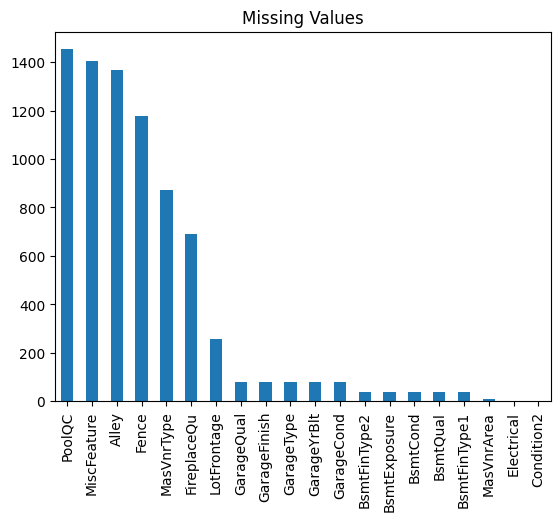

In [7]:
file.isnull().sum().sort_values(ascending=False).head(20).plot(kind='bar')
plt.title("Missing Values")

In [8]:
file.duplicated().sum()

np.int64(0)

## SalePrice [Target] Distribution

<Axes: xlabel='SalePrice', ylabel='Count'>

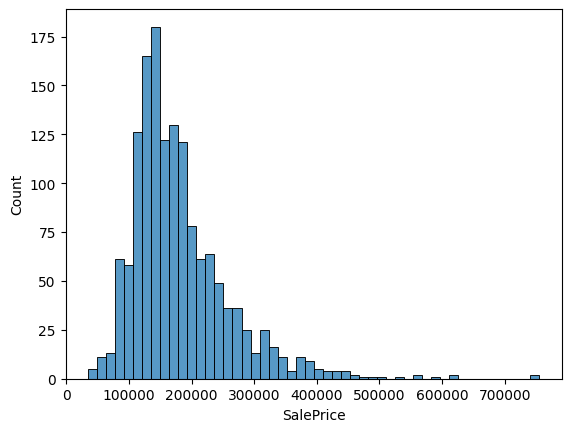

In [9]:
sns.histplot(file['SalePrice'], bins=50)

In [10]:
file['SalePrice'].mean()

np.float64(180921.19589041095)

# Target Vs Features

## 1\- General info

In [11]:
general_info = file[["MSSubClass", "MSZoning", "BldgType", "HouseStyle"]]


In [12]:
file[['MSSubClass','SalePrice']].corr()

,MSSubClass,SalePrice
MSSubClass,1.000000,-0.084284
SalePrice,-0.084284,1.000000


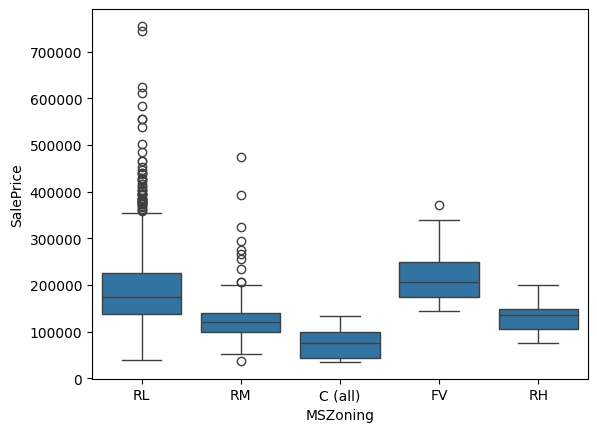

In [13]:
sns.boxplot(data=file,x='MSZoning',y='SalePrice')
plt.show()

The MSZoning feature has a noticeable impact on house prices\. Houses located in FV and RL zones generally have higher sale prices, while houses in C\(all\) have the lowest prices\. The RL category contains numerous high\-priced outliers, indicating the presence of luxury properties\. Overall, the distribution suggests that zoning classification is an important predictor of house prices\.

<Axes: xlabel='BldgType', ylabel='SalePrice'>

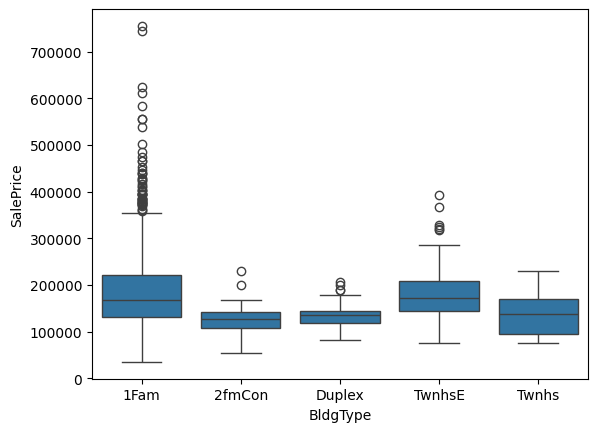

In [14]:
sns.boxplot(data=file,x='BldgType',y='SalePrice')


Single\-family homes \(1Fam\) and Townhouse End units \(TwnhsE\) command the highest median sale prices in the market\. Furthermore, 1Fam properties exhibit the highest price variance and contain significant upscale outliers, indicating that the luxury segment of the housing market is predominantly comprised of single\-family detached homes\. Conversely, duplexes and townhouses generally represent more affordable housing options with tighter price ranges\.

<Axes: xlabel='HouseStyle', ylabel='SalePrice'>

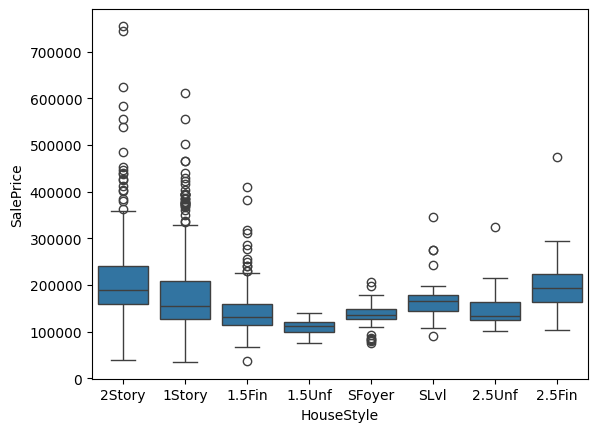

In [15]:
sns.boxplot(data=file,x='HouseStyle',y='SalePrice')

Premium Categories: Single\-family homes \(1Fam\), Townhouse End units \(TwnhsE\), and multi\-story styles \(2Story, 2\.5Fin\) drive the highest market value\.The Luxury Tier: The most expensive properties \(reaching $\\$400,000 \- \\$750,000\+$\) are almost entirely concentrated within 1Fam, 2Story, and 1Story categories, which display the widest price variance and heaviest high\-end outliers\.Budget Options: Duplexes, standard townhouses, and unfinished structures \(1\.5Unf\) consistently fall into the lower\-priced, more predictable segment of the market\.

# 2- Target Vs land_features

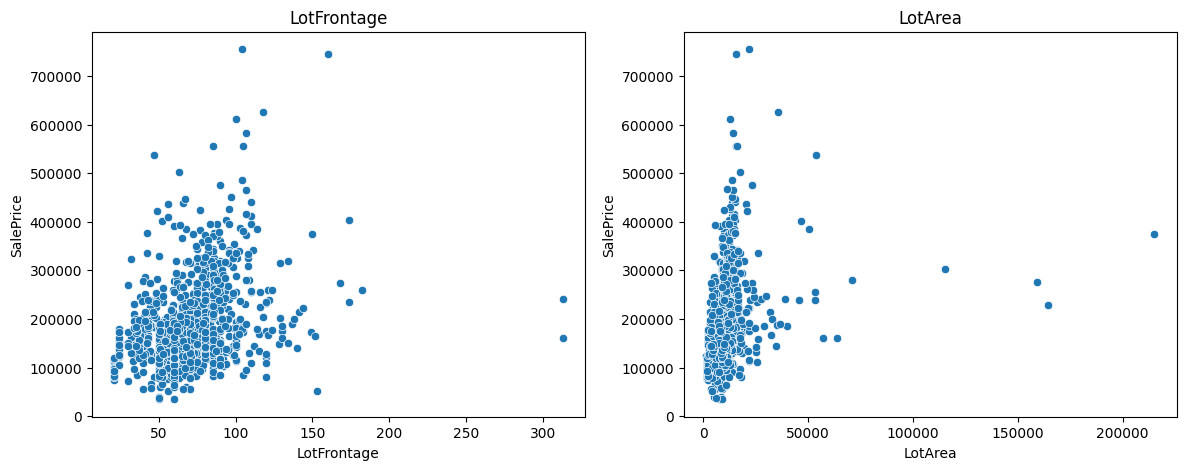

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))
sns.scatterplot(data=file,x="LotFrontage",y='SalePrice',ax=ax[0])
ax[0].set_title("LotFrontage")

sns.scatterplot(data=file,x="LotArea",y='SalePrice',ax=ax[1])
ax[1].set_title("LotArea")

plt.show()

In [17]:
print("LotArea corr: ",file[['LotArea','SalePrice']].corr())
print()
print("LotFrontage corr: ",file[['LotFrontage','SalePrice']].corr())

LotArea corr:              LotArea  SalePrice
LotArea    1.000000   0.263843
SalePrice  0.263843   1.000000

LotFrontage corr:               LotFrontage  SalePrice
LotFrontage     1.000000   0.351799
SalePrice       0.351799   1.000000


Both LotFrontage and LotArea show a positive but weak linear correlation with SalePrice, meaning larger land size does not automatically guarantee a higher price\. The majority of high\-value luxury homes \(above $500,000\) actually sit on moderate lot sizes and standard frontages\. Furthermore, both plots reveal extreme outliers on the right side, where massive properties sold at average prices, indicating that factors like location, build quality, and home size play a much more critical role in driving the property's ultimate value than the land size itself\.

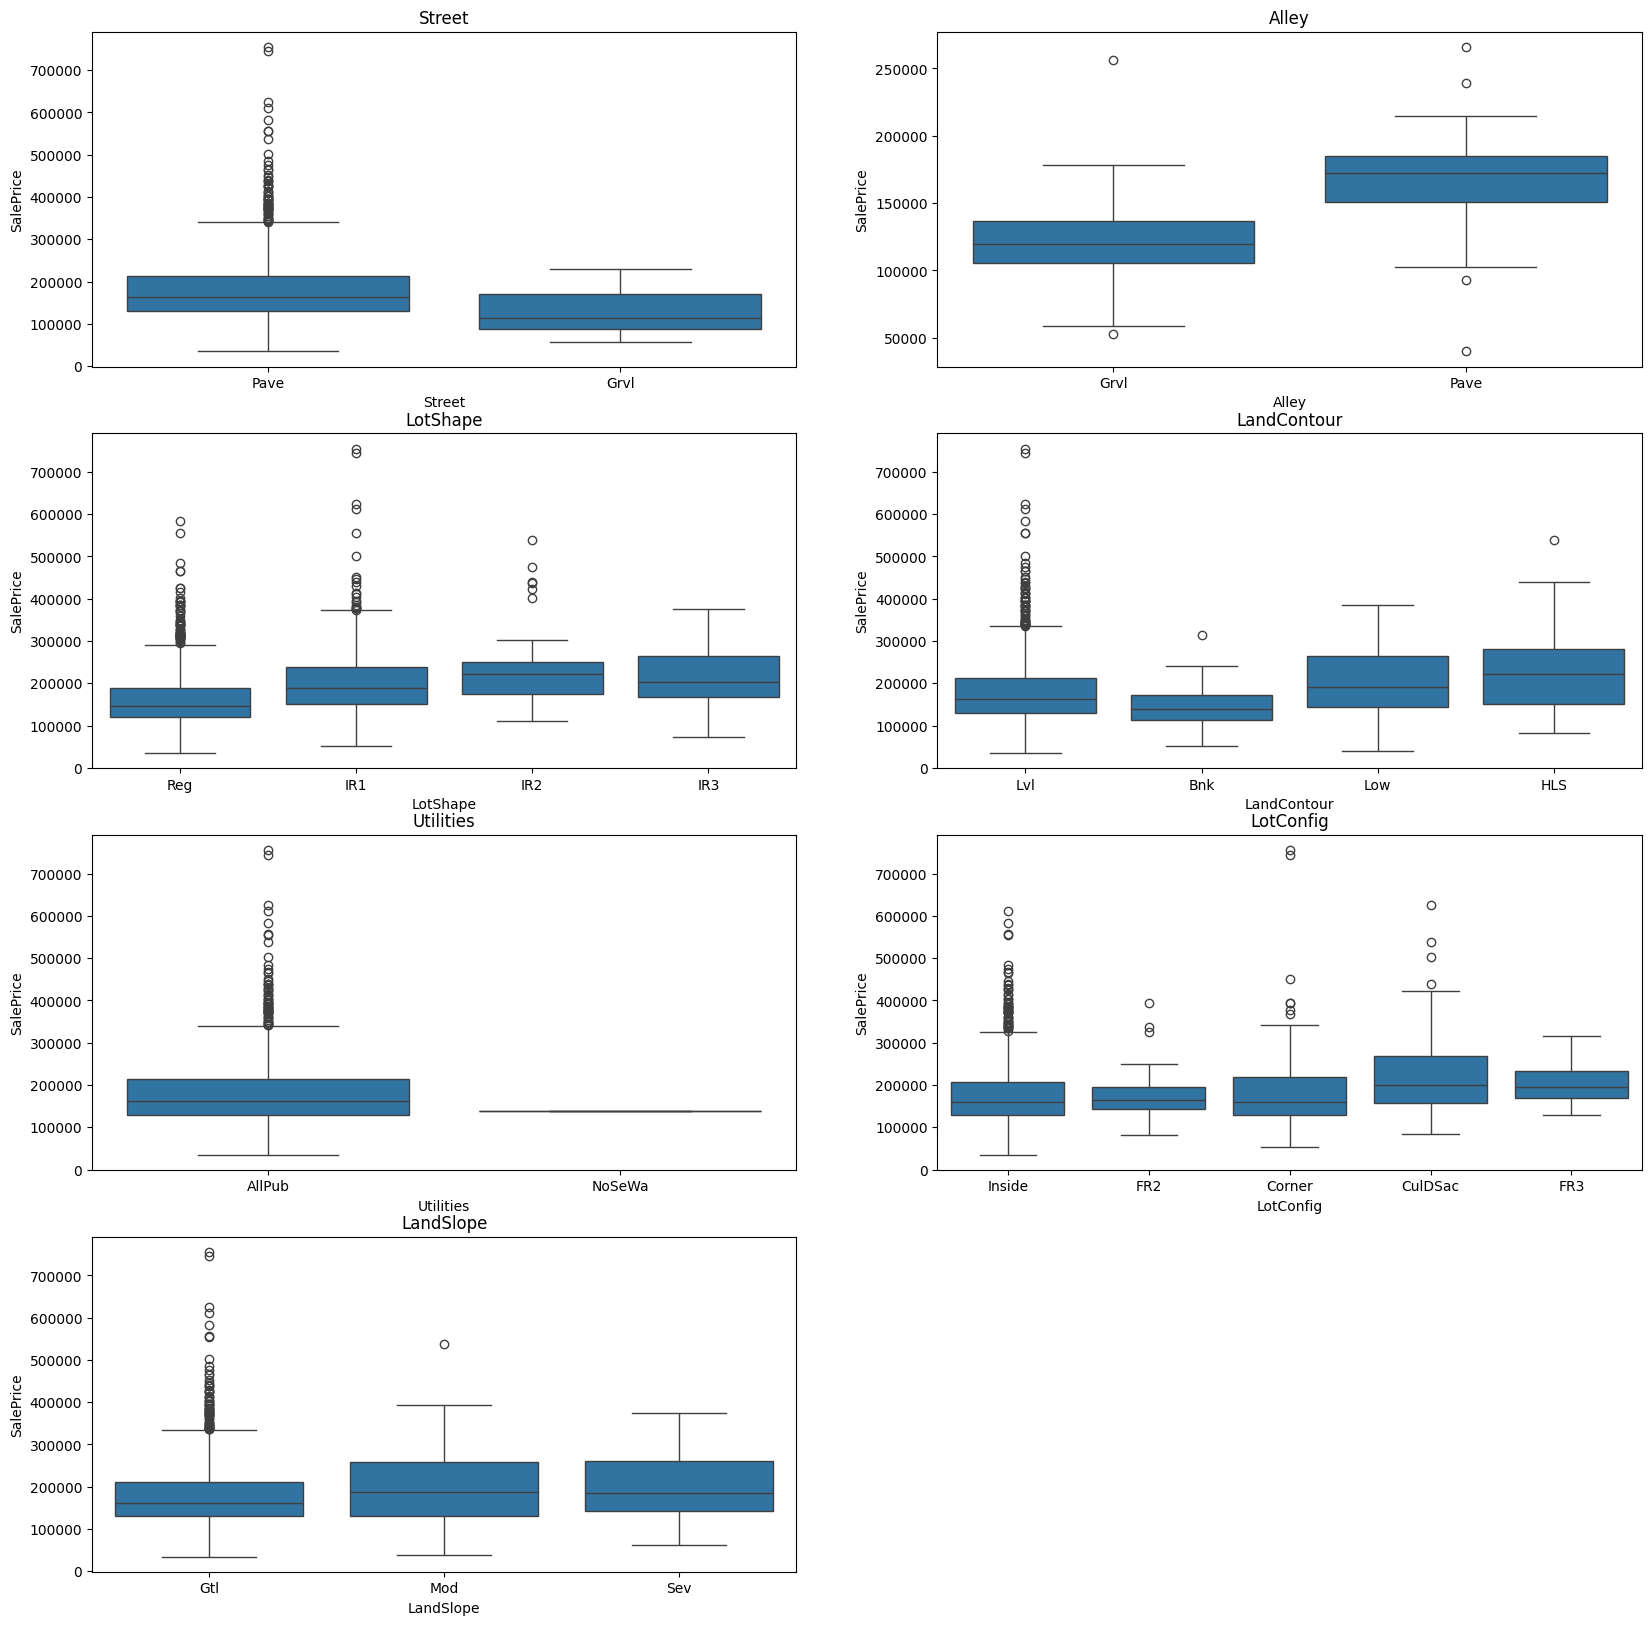

In [18]:
fig,ax =plt.subplots(4,2,figsize=(20,20))

sns.boxplot(data=file,x="Street",y="SalePrice",ax=ax[0][0])
ax[0][0].set_title("Street")

sns.boxplot(data=file,x="Alley",y="SalePrice",ax=ax[0][1])
ax[0][1].set_title("Alley")

sns.boxplot(data=file,x="LotShape",y="SalePrice",ax=ax[1][0])
ax[1][0].set_title("LotShape")

sns.boxplot(data=file,x="LandContour",y="SalePrice",ax=ax[1][1])
ax[1][1].set_title("LandContour")

sns.boxplot(data=file,x="Utilities",y="SalePrice",ax=ax[2][0])
ax[2][0].set_title("Utilities")

sns.boxplot(data=file,x="LotConfig",y="SalePrice",ax=ax[2][1])
ax[2][1].set_title("LotConfig")

sns.boxplot(data=file,x="LandSlope",y="SalePrice",ax=ax[3][0])
ax[3][0].set_title("LandSlope")

ax[3][1].axis("off")
plt.show()



In [19]:
land_features = file[["LotFrontage", "LotArea", "Street", "Alley","LotShape", "LandContour", "Utilities","LotConfig", "LandSlope"]]

In [20]:
file.groupby("Street")['SalePrice'].agg(
    count="count",median='median',mean='mean',min='min',max='max'
)


,count,median,mean,min,max
Street,,,,,
Grvl,6,114250.0,130190.500000,55993,228950
Pave,1454,163000.0,181130.538514,34900,755000


In [21]:
file["Alley"] = file["Alley"].fillna("NoAlley")

file.groupby("Alley")['SalePrice'].agg(
    count="count",median='median',mean='mean',min='min',max='max'
)

,count,median,mean,min,max
Alley,,,,,
Grvl,50,119500.0,122219.080000,52500,256000
NoAlley,1369,165000.0,183452.131483,34900,755000
Pave,41,172500.0,168000.585366,40000,265979


Most of the houses \(1369 out of 1460\) have no back alley \(NoAlley\)\. Houses with a paved back alley \(Pave\) have the highest median selling price, while houses with a dirt driveway \(Grvl\) have the lowest\. However, the Pave and Grvl categories have fewer samples than the NoAlley category, so the effect of this variable on selling price appears limited and should be interpreted with caution\.


In [22]:
file.groupby("LotShape")['SalePrice'].agg(
    count="count",median='median',mean='mean',min='min',max='max'
)

,count,median,mean,min,max
LotShape,,,,,
IR1,484,189000.0,206101.665289,52000,755000
IR2,41,221000.0,239833.365854,110000,538000
IR3,10,203570.0,216036.500000,73000,375000
Reg,925,146000.0,164754.818378,34900,582933


The LotShape feature shows a noticeable relationship with SalePrice\. Houses with slightly irregular lots \(IR1\) have a significantly higher median sale price than houses with regular lots \(Reg\)\. Although IR2 and IR3 also exhibit higher prices, these categories contain relatively few observations, making their estimates less reliable\.

In [23]:
file.groupby("LandContour")['SalePrice'].agg(
    count="count",median='median',mean='mean',min='min',max='max'
)

,count,median,mean,min,max
LandContour,,,,,
Bnk,63,139400.0,143104.079365,52500,315000
HLS,50,222250.0,231533.940000,82500,538000
Low,36,190000.0,203661.111111,39300,385000
Lvl,1311,162900.0,180183.746758,34900,755000


LandContour shows a clear correlation with selling price\.

HLS\-type homes have the highest prices\.

Bnk\-type homes have the lowest prices\.

However, it should be noted that the HLS and Low categories have a small sample size, so their results should be interpreted with caution\.

In [24]:
file.groupby("Utilities")['SalePrice'].agg(
    count="count",median='median',mean='mean',min='min',max='max'
)

,count,median,mean,min,max
Utilities,,,,,
AllPub,1459,163000.0,180950.95682,34900,755000
NoSeWa,1,137500.0,137500.00000,137500,137500


The Utilities column contains one dominant class \(AllPub\) that represents almost all the data, while the other class \(NoSeWa\) contains only one note\. Therefore, this column does not provide enough variance to help the model make predictions, and is considered a Near\-Zero Variance Feature\.

In [25]:
file.drop(columns='Utilities',inplace=True)

In [26]:
file.groupby("LotConfig")['SalePrice'].agg(
    count="count",median='median',mean='mean',min='min',max='max'
)

,count,median,mean,min,max
LotConfig,,,,,
Corner,263,160000.0,181623.425856,52500,755000
CulDSac,94,199262.0,223854.617021,84000,625000
FR2,47,165000.0,177934.574468,81000,394617
FR3,4,195450.0,208475.000000,128000,315000
Inside,1052,159697.5,176938.047529,34900,611657


LotConfig has a moderate to good effect on the selling price\.

The CulDSac category has higher prices than the other categories; this conclusion is based on 94 observations, which is a relatively acceptable number\.

Reliable conclusions cannot be drawn for the FR3 category due to the limited sample size\.

In [27]:
file.groupby("LandSlope")['SalePrice'].agg(
    count="count",median='median',mean='mean',min='min',max='max'
)

,count,median,mean,min,max
LandSlope,,,,,
Gtl,1382,161875.0,179956.799566,34900,755000
Mod,65,186700.0,196734.138462,39300,538000
Sev,13,185000.0,204379.230769,61000,375000


The LandSlope column shows some correlation with SalePrice, with homes on a medium slope \(Mod\) having a higher median price than homes on a simple slope \(Gtl\)\. However, most of the data falls into the Gtl category, while the Sev category contains only 13 observations, so the effect of this variable appears limited and should be interpreted with caution\.

# 3- Target Vs location

In [28]:
location = file[["Neighborhood", "Condition1", "Condition2"]]


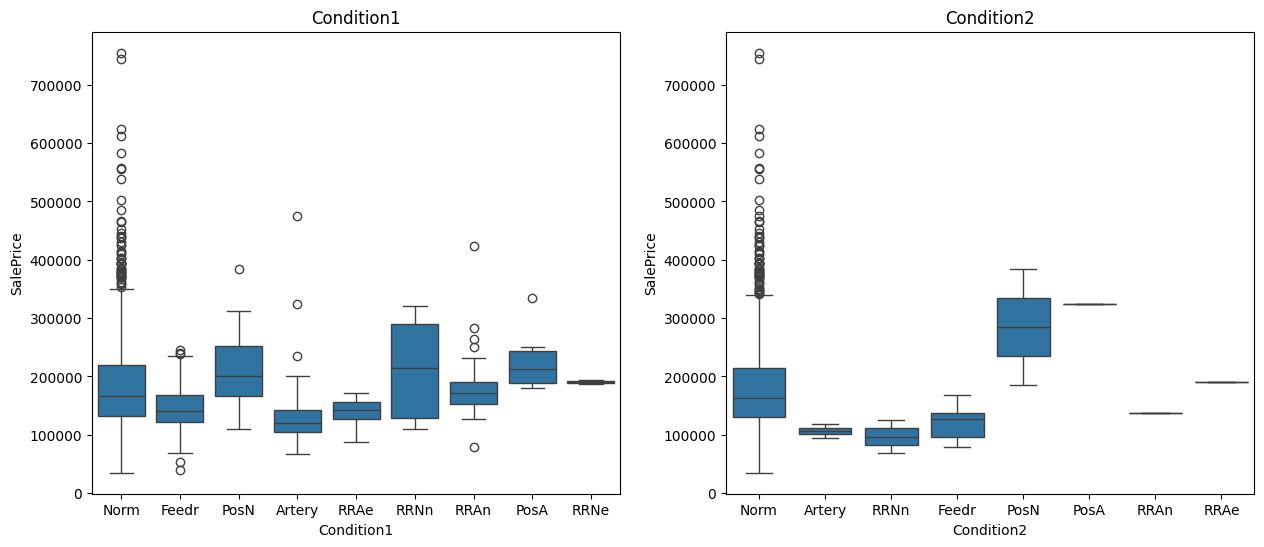

In [29]:
fig,ax =plt.subplots(1,2,figsize=(15,6))

sns.boxplot(data=file,x="Condition1",y="SalePrice",ax=ax[0])
ax[0].set_title("Condition1")

sns.boxplot(data=file,x="Condition2",y="SalePrice",ax=ax[1])
ax[1].set_title("Condition2")

plt.show()

In [30]:
file.groupby("Condition1")['SalePrice'].agg(
    count="count",median='median',mean='mean'
)

,count,median,mean
Condition1,,,
Artery,48,119550.0,135091.666667
Feedr,81,140000.0,142475.481481
Norm,1260,166500.0,184495.492063
PosA,8,212500.0,225875.000000
PosN,19,200000.0,215184.210526
RRAe,11,142500.0,138400.000000
RRAn,26,171495.0,184396.615385
RRNe,2,190750.0,190750.000000
RRNn,5,214000.0,212400.000000


Condition 1 shows a moderate impact on home prices\.

The Artery and Feedr categories are associated with lower prices compared to Norm\.

The PosN and PosA categories are associated with higher prices, but their sample sizes are relatively small\.

Some other categories cannot be evaluated due to the limited number of homes\.

In [31]:
file.groupby("Condition2")['SalePrice'].agg(
    count="count",median='median',mean='mean'
)

,count,median,mean
Condition2,,,
Artery,2,106500.0,106500.000000
Feedr,6,127500.0,121166.666667
Norm,1445,163500.0,181169.405536
PosA,1,325000.0,325000.000000
PosN,2,284875.0,284875.000000
RRAe,1,190000.0,190000.000000
RRAn,1,136905.0,136905.000000
RRNn,2,96750.0,96750.000000


The Condition2 column does not show sufficient data variation, as approximately 99% of the houses fall into the Norm category, while all other categories contain very few observations\. Therefore, reliable differences between categories cannot be inferred, and this column is not expected to provide useful information to the model\.

In [32]:
file.drop(columns="Condition2",inplace=True)

In [33]:
file.groupby("Neighborhood")['SalePrice'].agg(
    count="count",median='median',mean='mean'
).sort_values(by='median',ascending=False)

,count,median,mean
Neighborhood,,,
NridgHt,77,315000.0,316270.623377
NoRidge,41,301500.0,335295.317073
StoneBr,25,278000.0,310499.000000
Timber,38,228475.0,242247.447368
Somerst,86,225500.0,225379.837209
Veenker,11,218000.0,238772.727273
Crawfor,51,200624.0,210624.725490
ClearCr,28,200250.0,212565.428571
CollgCr,150,197200.0,197965.773333


There are significant differences between neighborhoods, with the median in some areas like NridgHt and NoRidge being over $200,000 higher than in areas like IDOTRR and BrDale\. Many of these neighborhoods also have a good number of homes, which makes the results more reliable\.

# 4- Target Vs Quality Age 

In [34]:
quality_age = file[["OverallQual", "OverallCond","YearBuilt", "YearRemodAdd"]]


In [35]:
file[['OverallQual','SalePrice']].corr()

,OverallQual,SalePrice
OverallQual,1.000000,0.790982
SalePrice,0.790982,1.000000


<Axes: xlabel='OverallQual', ylabel='SalePrice'>

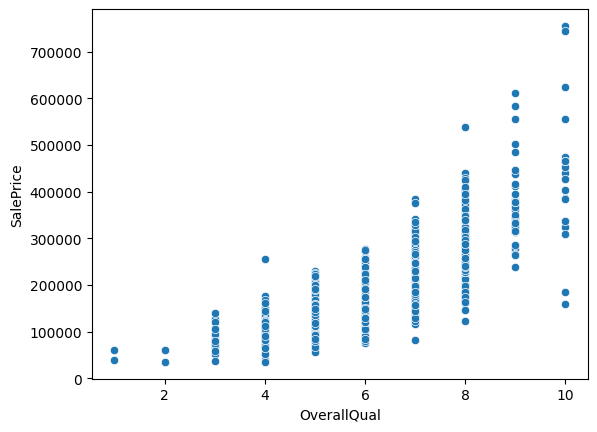

In [36]:
sns.scatterplot(data=file,x='OverallQual',y='SalePrice')

OverallQual exhibits a very strong positive correlation with SalePrice \(r = 0\.79\), indicating that houses with higher overall construction and material quality tend to have significantly higher selling prices\. This feature is expected to be one of the most important predictors in the model\.

In [37]:
file[['OverallCond','SalePrice']].corr()

,OverallCond,SalePrice
OverallCond,1.000000,-0.077856
SalePrice,-0.077856,1.000000


OverallCond shows a very weak negative linear correlation with SalePrice \(r = \-0\.078\)\. This suggests that the overall condition of the house alone is not a strong linear predictor of sale price\. However, further analysis using boxplots and grouped statistics is recommended because the relationship may be non\-linear or influenced by other features\.

In [38]:
file.drop(columns='OverallCond',inplace=True)

<Axes: xlabel='YearBuilt', ylabel='SalePrice'>

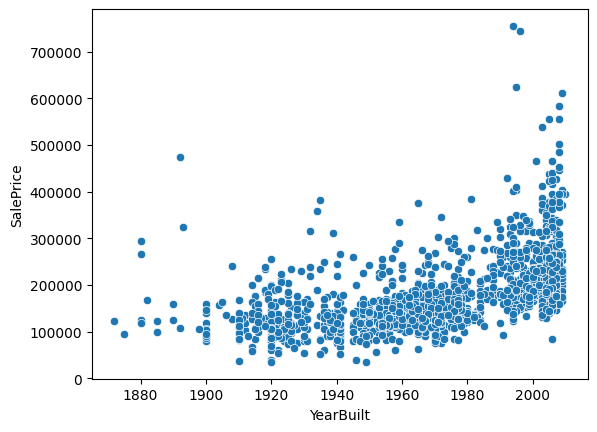

In [39]:
sns.scatterplot(data=file,x='YearBuilt',y='SalePrice')

In [40]:
file[['YearBuilt','SalePrice']].corr()

,YearBuilt,SalePrice
YearBuilt,1.000000,0.522897
SalePrice,0.522897,1.000000


YearBuilt has a moderately strong positive correlation with SalePrice \(r = 0\.523\)\. This indicates that newer houses generally sell at higher prices\. The scatter plot also confirms an upward trend, although the relationship is not perfectly linear due to the variability in house prices\.

              YearRemodAdd  SalePrice
YearRemodAdd      1.000000   0.507101
SalePrice         0.507101   1.000000


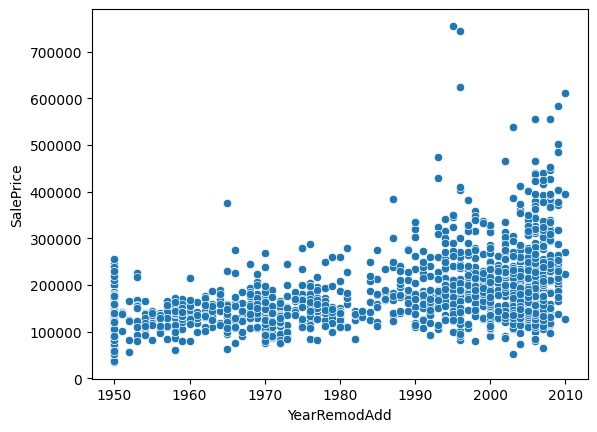

In [41]:
sns.scatterplot(data=file,x='YearRemodAdd',y='SalePrice')
print(file[['YearRemodAdd','SalePrice']].corr())

YearRemodAdd shows a moderately strong positive correlation with SalePrice \(r = 0\.507\), indicating that houses renovated more recently tend to have higher selling prices\. This feature captures the effect of renovations and improvements, making it a valuable predictor alongside YearBuilt\.

In [42]:
print(file[['YearRemodAdd','YearBuilt']].corr())

              YearRemodAdd  YearBuilt
YearRemodAdd      1.000000   0.592855
YearBuilt         0.592855   1.000000


# 5- Target Vs Exterior

In [43]:
exterior = file[["RoofStyle", "RoofMatl", "Exterior1st","Exterior2nd", "MasVnrType", "MasVnrArea","ExterQual", "ExterCond"]]


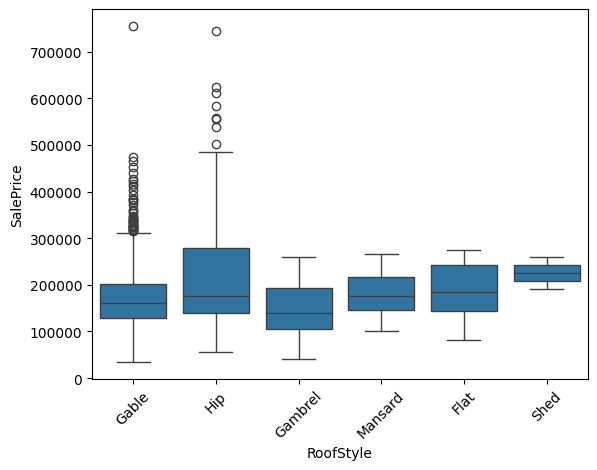

,count,median,mean
RoofStyle,,,
Flat,13,185000.0,194690.000000
Gable,1141,160000.0,171483.956179
Gambrel,11,139000.0,148909.090909
Hip,286,176500.0,218876.933566
Mansard,7,175000.0,180568.428571
Shed,2,225000.0,225000.000000


In [44]:
sns.boxplot(data=file, x="RoofStyle", y="SalePrice")
plt.xticks(rotation=45)
plt.show()

file.groupby("RoofStyle")["SalePrice"].agg(
    count="count",
    median="median",
    mean="mean"
)

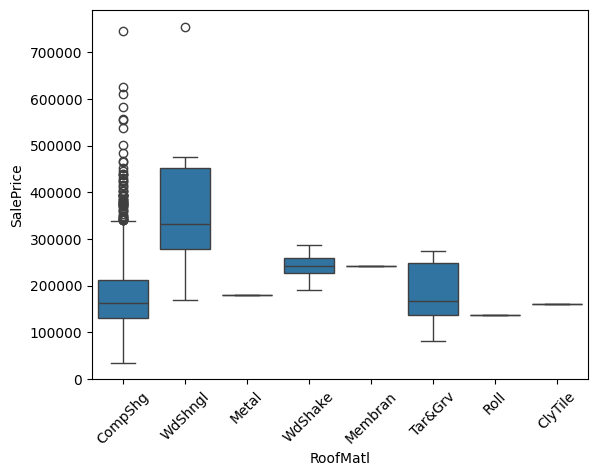

,count,median,mean
RoofMatl,,,
ClyTile,1,160000.0,160000.000000
CompShg,1434,162000.0,179803.679219
Membran,1,241500.0,241500.000000
Metal,1,180000.0,180000.000000
Roll,1,137000.0,137000.000000
Tar&Grv,11,167000.0,185406.363636
WdShake,5,242000.0,241400.000000
WdShngl,6,332500.0,390250.000000


In [45]:
sns.boxplot(data=file, x="RoofMatl", y="SalePrice")
plt.xticks(rotation=45)
plt.show()

file.groupby("RoofMatl")["SalePrice"].agg(
    count="count",
    median="median",
    mean="mean"
)

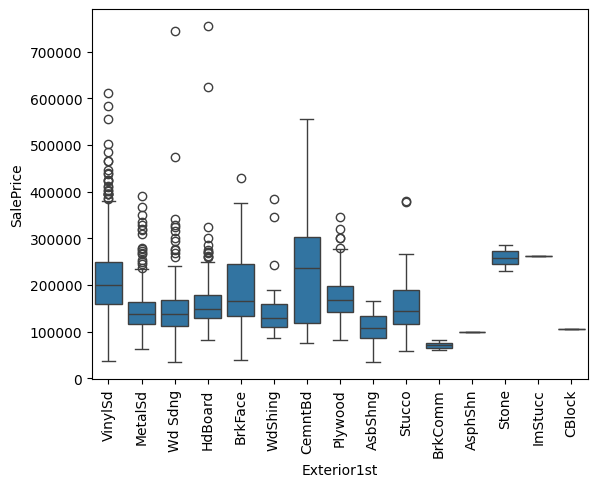

,count,median,mean
Exterior1st,,,
AsbShng,20,108000.0,107385.550000
AsphShn,1,100000.0,100000.000000
BrkComm,2,71000.0,71000.000000
BrkFace,50,165750.0,194573.000000
CBlock,1,105000.0,105000.000000
CemntBd,61,236500.0,231690.655738
HdBoard,222,149900.0,163077.450450
ImStucc,1,262000.0,262000.000000
MetalSd,220,139000.0,149422.177273


In [46]:
sns.boxplot(data=file, x="Exterior1st", y="SalePrice")
plt.xticks(rotation=90)
plt.show()

file.groupby("Exterior1st")["SalePrice"].agg(
    count="count",
    median="median",
    mean="mean"
)

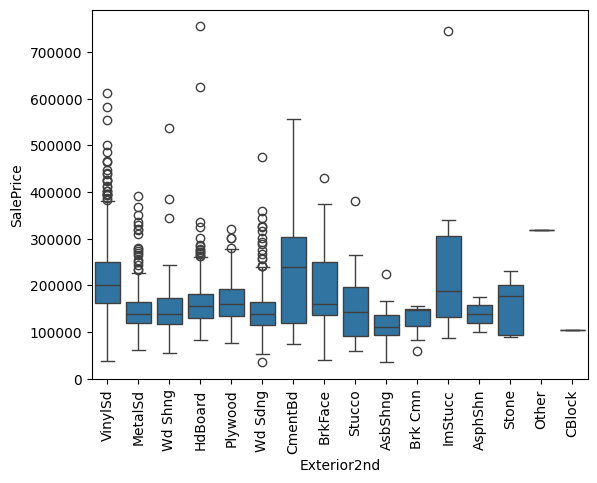

,count,median,mean
Exterior2nd,,,
AsbShng,20,111000.0,114060.550000
AsphShn,3,139000.0,138000.000000
Brk Cmn,7,147000.0,126714.285714
BrkFace,25,160000.0,195818.000000
CBlock,1,105000.0,105000.000000
CmentBd,60,238750.0,230093.833333
HdBoard,207,155000.0,167661.565217
ImStucc,10,187600.0,252070.000000
MetalSd,214,138750.0,149803.172897


In [47]:
sns.boxplot(data=file, x="Exterior2nd", y="SalePrice")
plt.xticks(rotation=90)
plt.show()

file.groupby("Exterior2nd")["SalePrice"].agg(
    count="count",
    median="median",
    mean="mean"
)

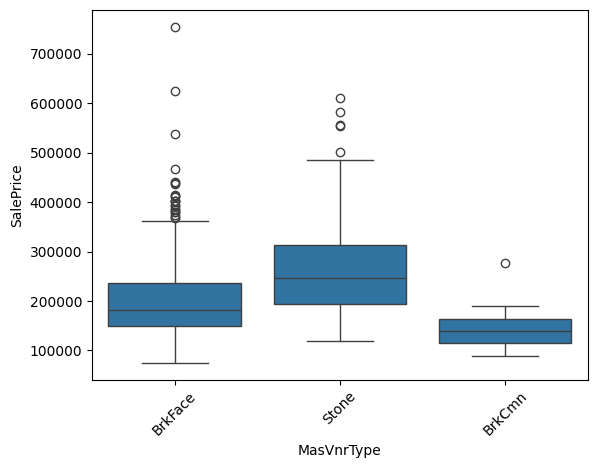

,count,median,mean
MasVnrType,,,
BrkCmn,15,139000.0,146318.066667
BrkFace,445,181000.0,204691.871910
Stone,128,246839.0,265583.625000


In [48]:
sns.boxplot(data=file, x="MasVnrType", y="SalePrice")
plt.xticks(rotation=45)
plt.show()

file.groupby("MasVnrType")["SalePrice"].agg(
    count="count",
    median="median",
    mean="mean"
)

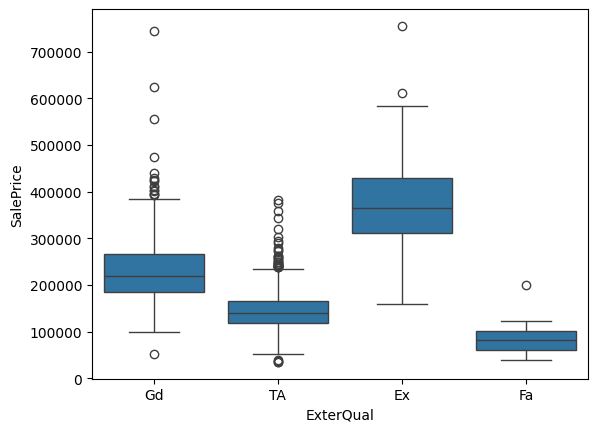

,count,median,mean
ExterQual,,,
Ex,52,364606.5,367360.961538
Fa,14,82250.0,87985.214286
Gd,488,220000.0,231633.510246
TA,906,139450.0,144341.313466


In [49]:
sns.boxplot(data=file, x="ExterQual", y="SalePrice")
plt.show()

file.groupby("ExterQual")["SalePrice"].agg(
    count="count",
    median="median",
    mean="mean"
)

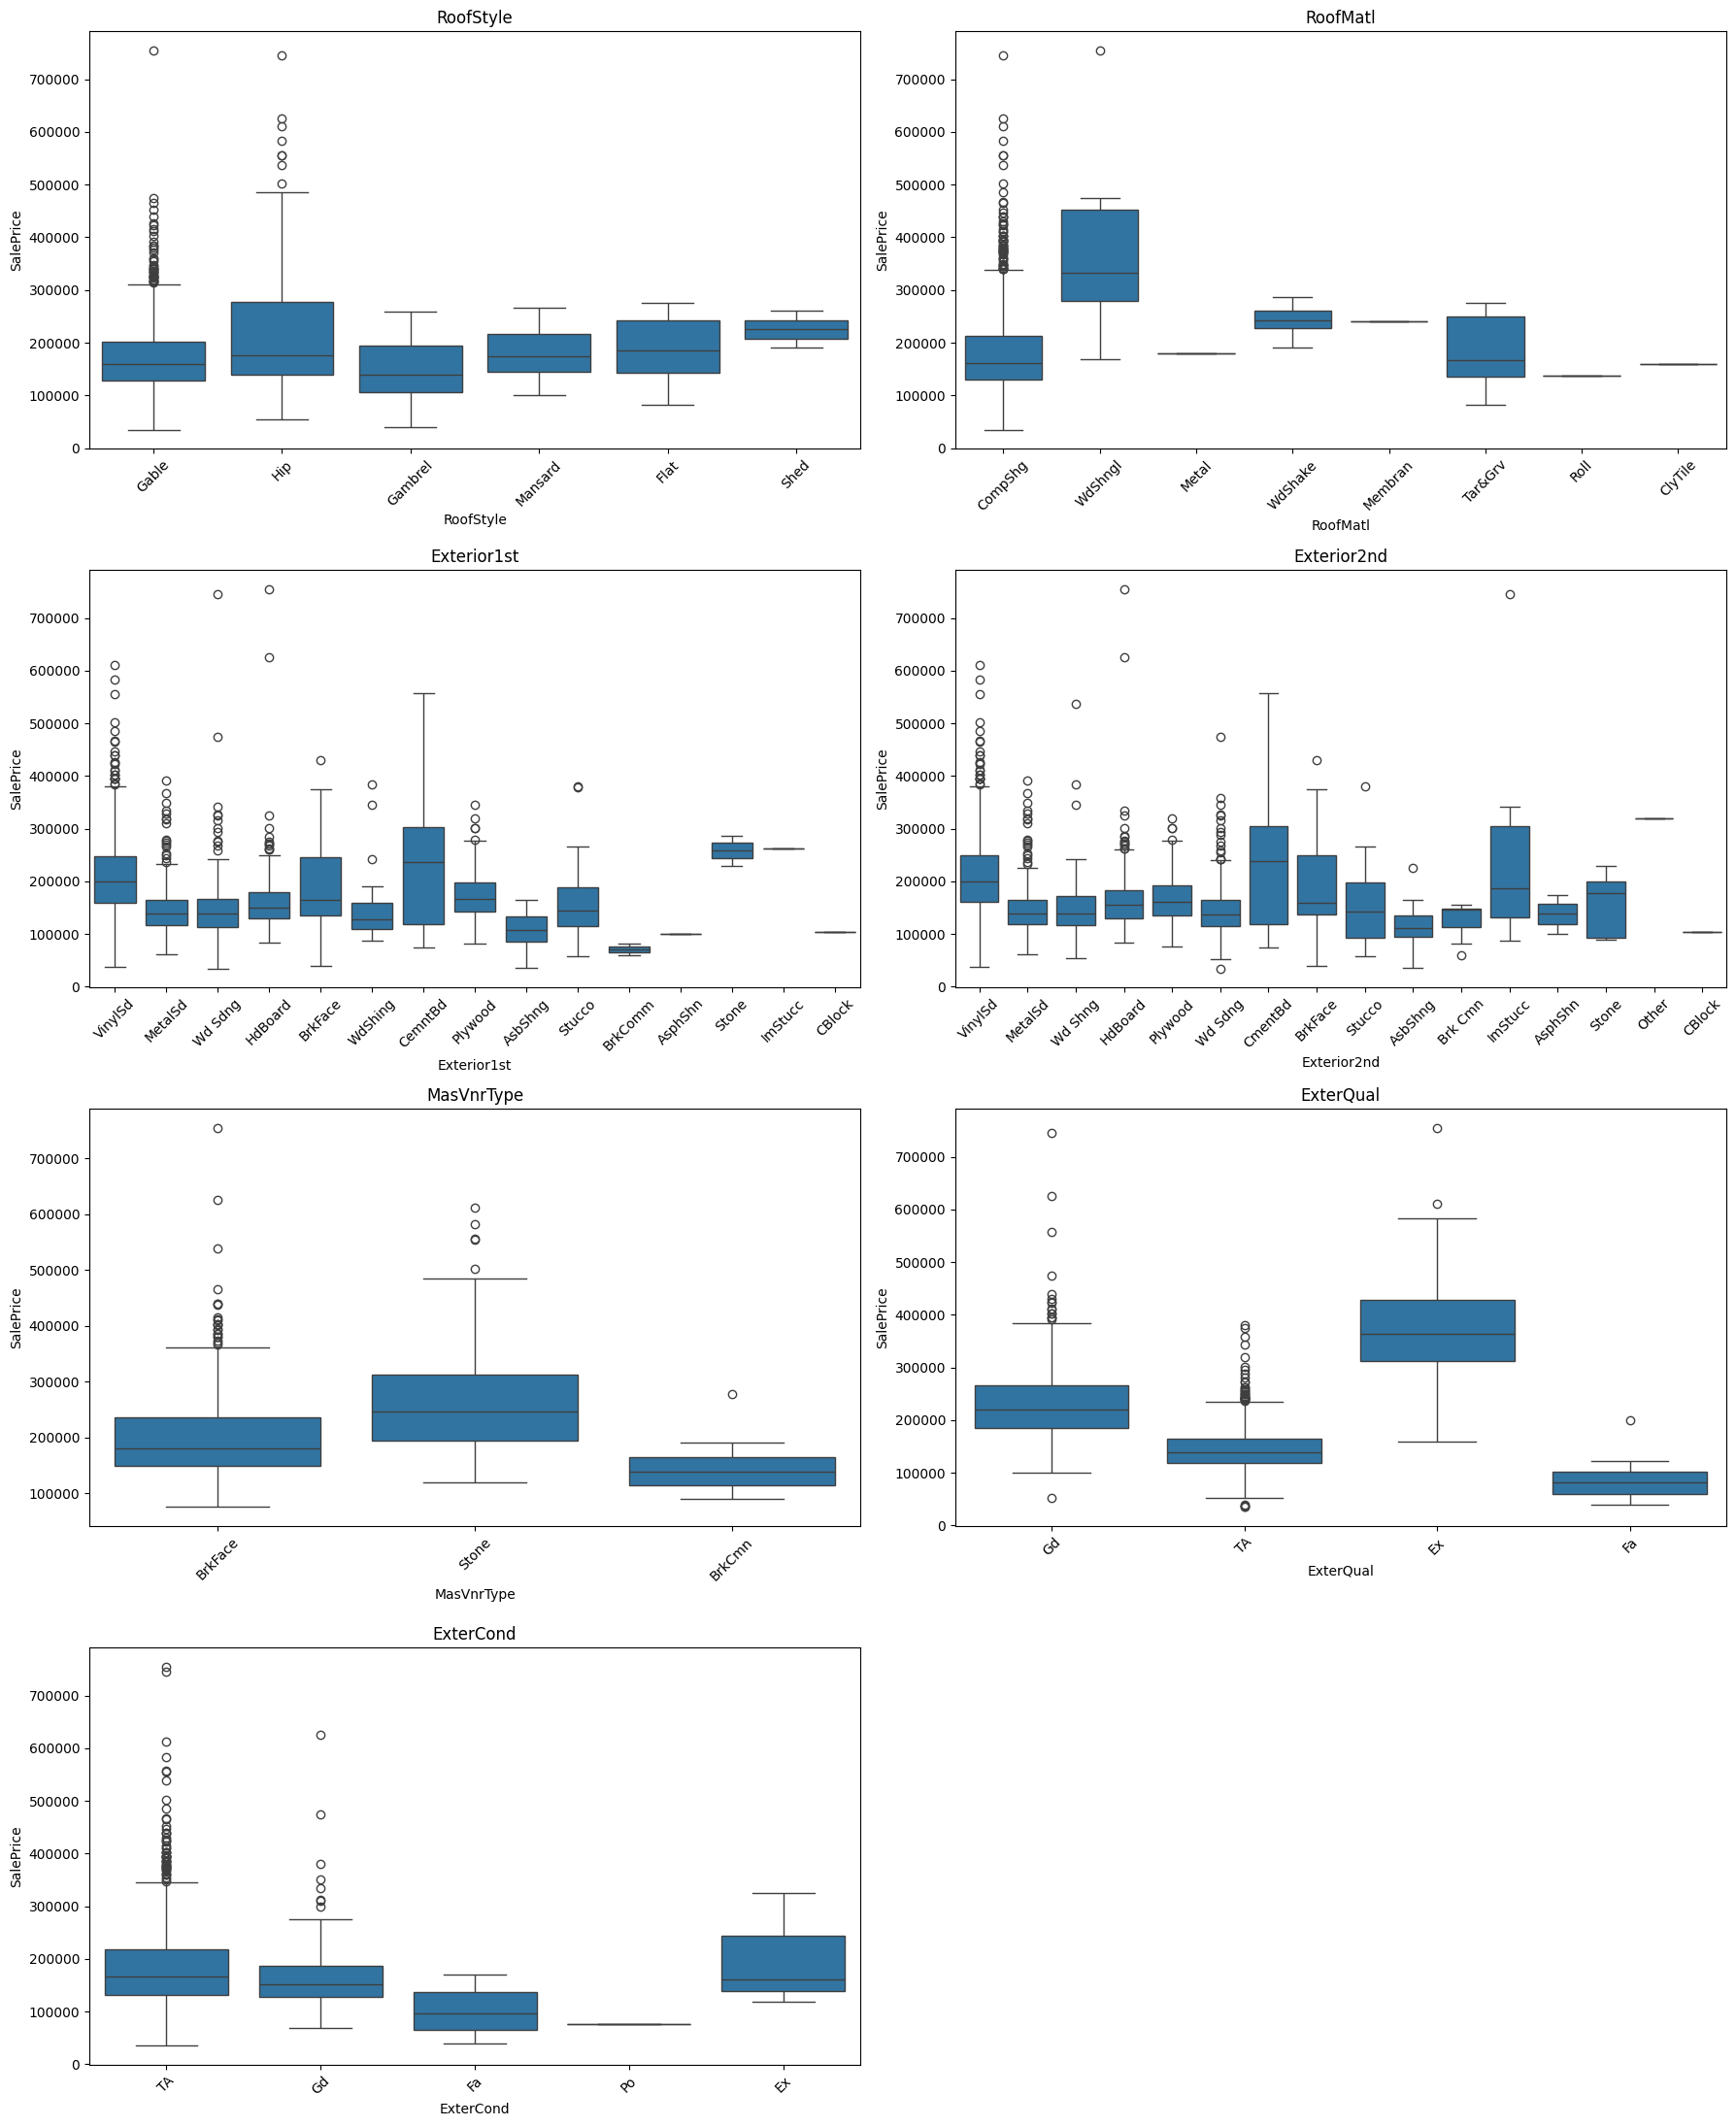

In [50]:
features = [
    "RoofStyle", "RoofMatl", "Exterior1st",
    "Exterior2nd", "MasVnrType",
    "ExterQual", "ExterCond"
]

fig, axes = plt.subplots(4, 2, figsize=(18, 22))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(data=file, x=col, y="SalePrice", ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=45)

fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

In [51]:
file[['MasVnrArea','SalePrice']].corr()

,MasVnrArea,SalePrice
MasVnrArea,1.000000,0.477493
SalePrice,0.477493,1.000000


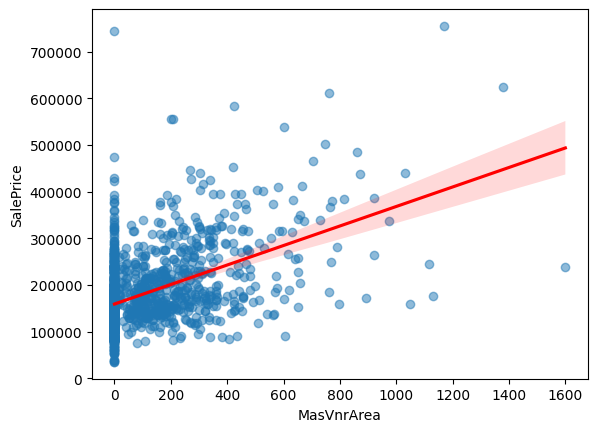

In [52]:
sns.regplot(
    data=file,
    x="MasVnrArea",
    y="SalePrice",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)
plt.show()

# 6- Target Vs Foundation Basement

In [53]:
foundation_basement = file[["Foundation", "BsmtQual", "BsmtCond","BsmtExposure", "BsmtFinType1", "BsmtFinSF1","BsmtFinType2", "BsmtFinSF2","BsmtUnfSF", "TotalBsmtSF"]]


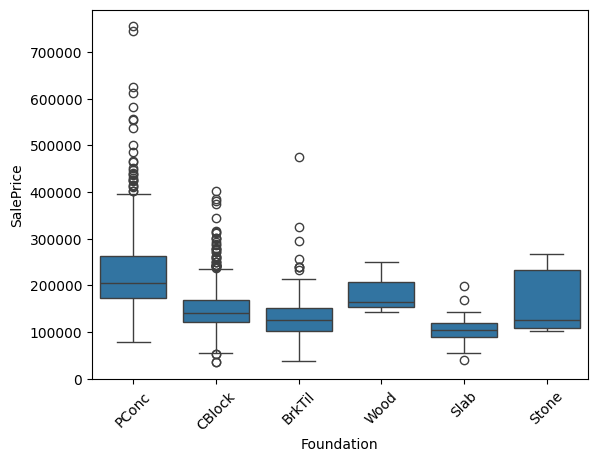

,count,median,mean
Foundation,,,
BrkTil,146,125250.0,132291.075342
CBlock,634,141500.0,149805.714511
PConc,647,205000.0,225230.442040
Slab,24,104150.0,107365.625000
Stone,6,126500.0,165959.166667
Wood,3,164000.0,185666.666667


In [54]:
sns.boxplot(data=file, x="Foundation", y="SalePrice")
plt.xticks(rotation=45)
plt.show()

file.groupby("Foundation")["SalePrice"].agg(
    count="count",
    median="median",
    mean="mean"
)

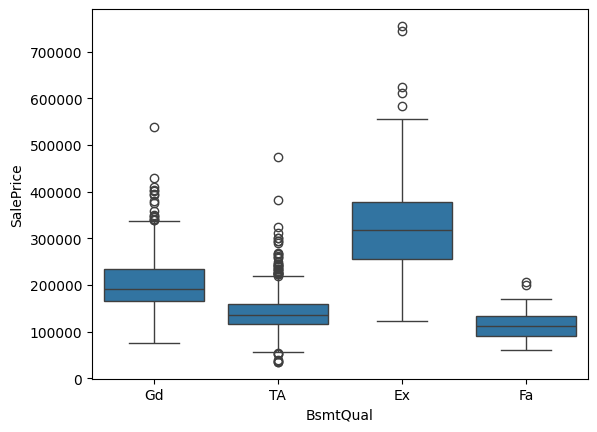

,count,median,mean
BsmtQual,,,
Ex,121,318000.0,327041.041322
Fa,35,112000.0,115692.028571
Gd,618,192070.0,202688.478964
TA,649,135500.0,140759.818182


In [55]:
sns.boxplot(data=file, x="BsmtQual", y="SalePrice")
plt.show()

file.groupby("BsmtQual")["SalePrice"].agg(
    count="count",
    median="median",
    mean="mean"
)

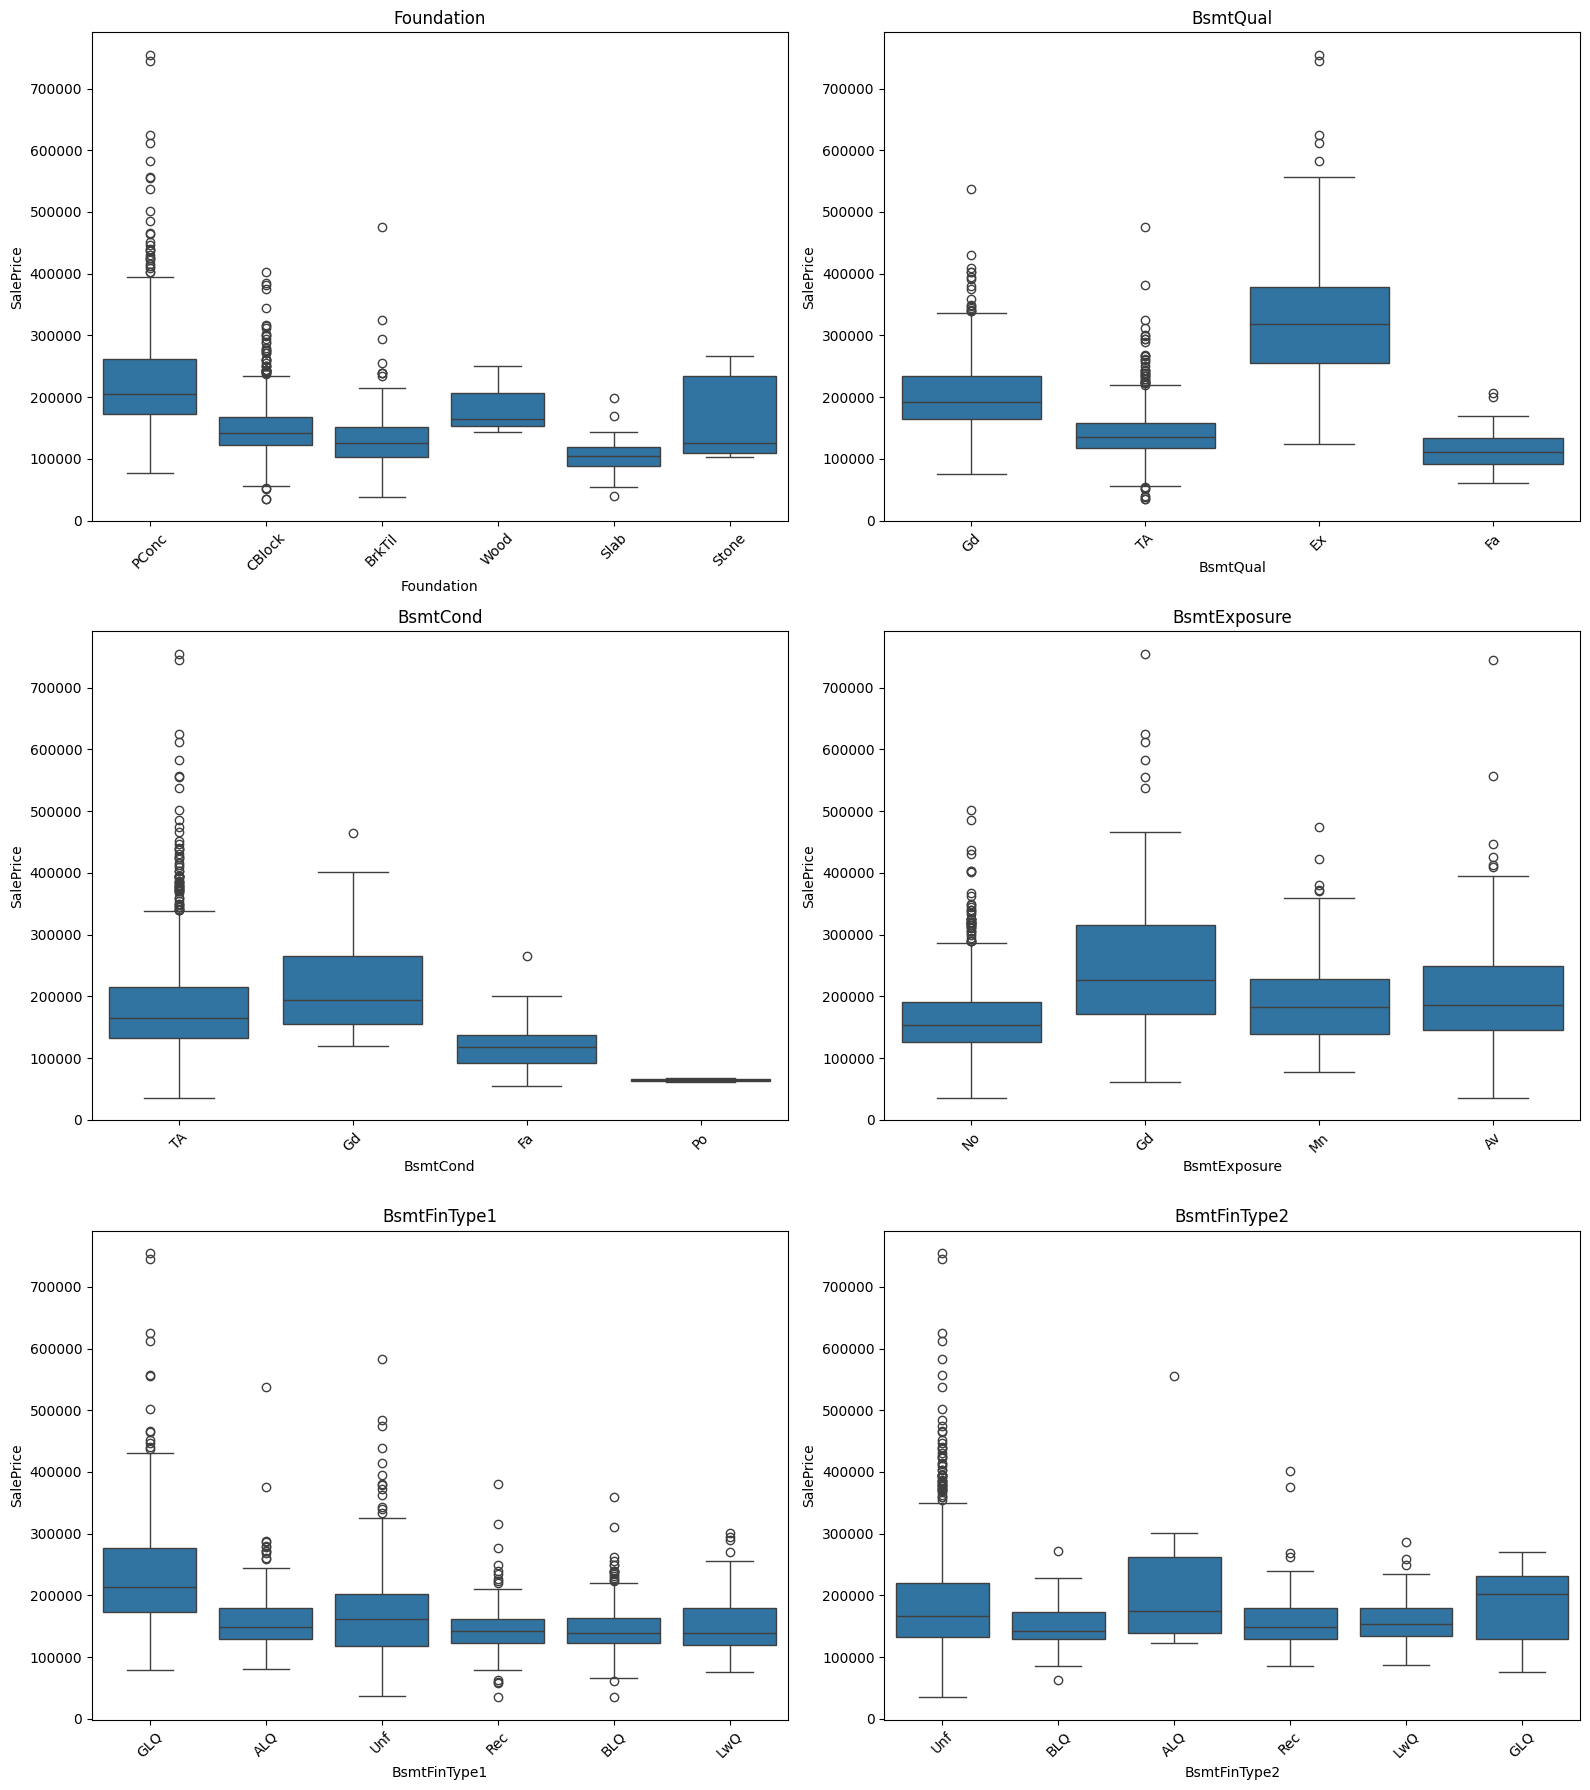

In [56]:
features = [
    "Foundation",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2"
]

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(data=file, x=col, y="SalePrice", ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [57]:
foundation_basement_num = file[
    [
        "BsmtFinSF1",
        "BsmtFinSF2",
        "BsmtUnfSF",
        "TotalBsmtSF"
    ]
]

for col in foundation_basement_num.columns:
    print(col)
    print(file[[col, "SalePrice"]].corr())

BsmtFinSF1
            BsmtFinSF1  SalePrice
BsmtFinSF1     1.00000    0.38642
SalePrice      0.38642    1.00000
BsmtFinSF2
            BsmtFinSF2  SalePrice
BsmtFinSF2    1.000000  -0.011378
SalePrice    -0.011378   1.000000
BsmtUnfSF
           BsmtUnfSF  SalePrice
BsmtUnfSF   1.000000   0.214479
SalePrice   0.214479   1.000000
TotalBsmtSF
             TotalBsmtSF  SalePrice
TotalBsmtSF     1.000000   0.613581
SalePrice       0.613581   1.000000


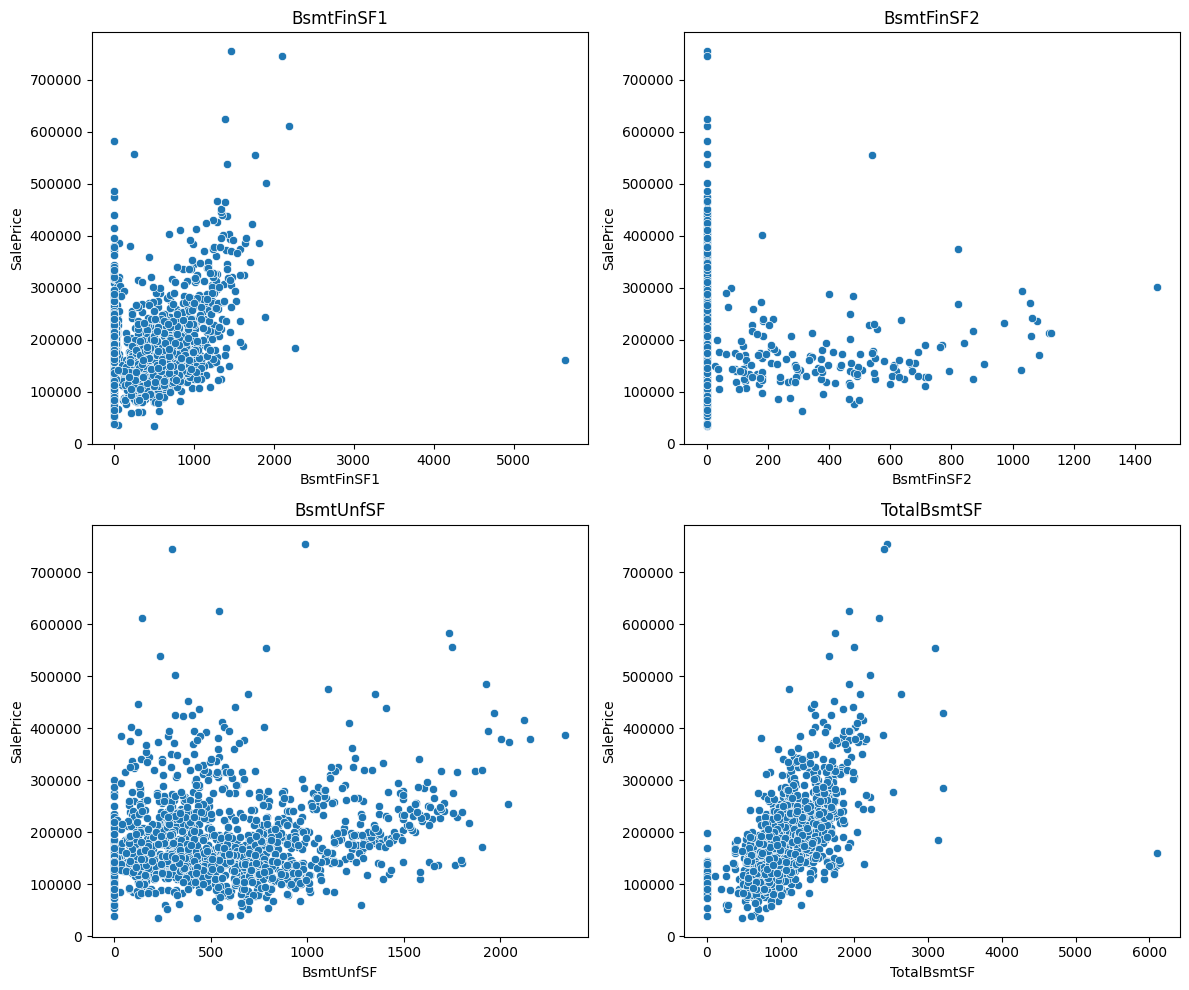

In [58]:
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
ax = ax.flatten()

for i, col in enumerate(foundation_basement_num.columns):
    sns.scatterplot(data=file, x=col, y="SalePrice", ax=ax[i])
    ax[i].set_title(col)

plt.tight_layout()
plt.show()

Among the basement\-related numerical features, TotalBsmtSF is the strongest predictor of house prices, followed by BsmtFinSF1\. In contrast, BsmtUnfSF has only a weak contribution, while BsmtFinSF2 shows almost no linear relationship with the target variable\.

# 7- Target Vs Heating Utilities

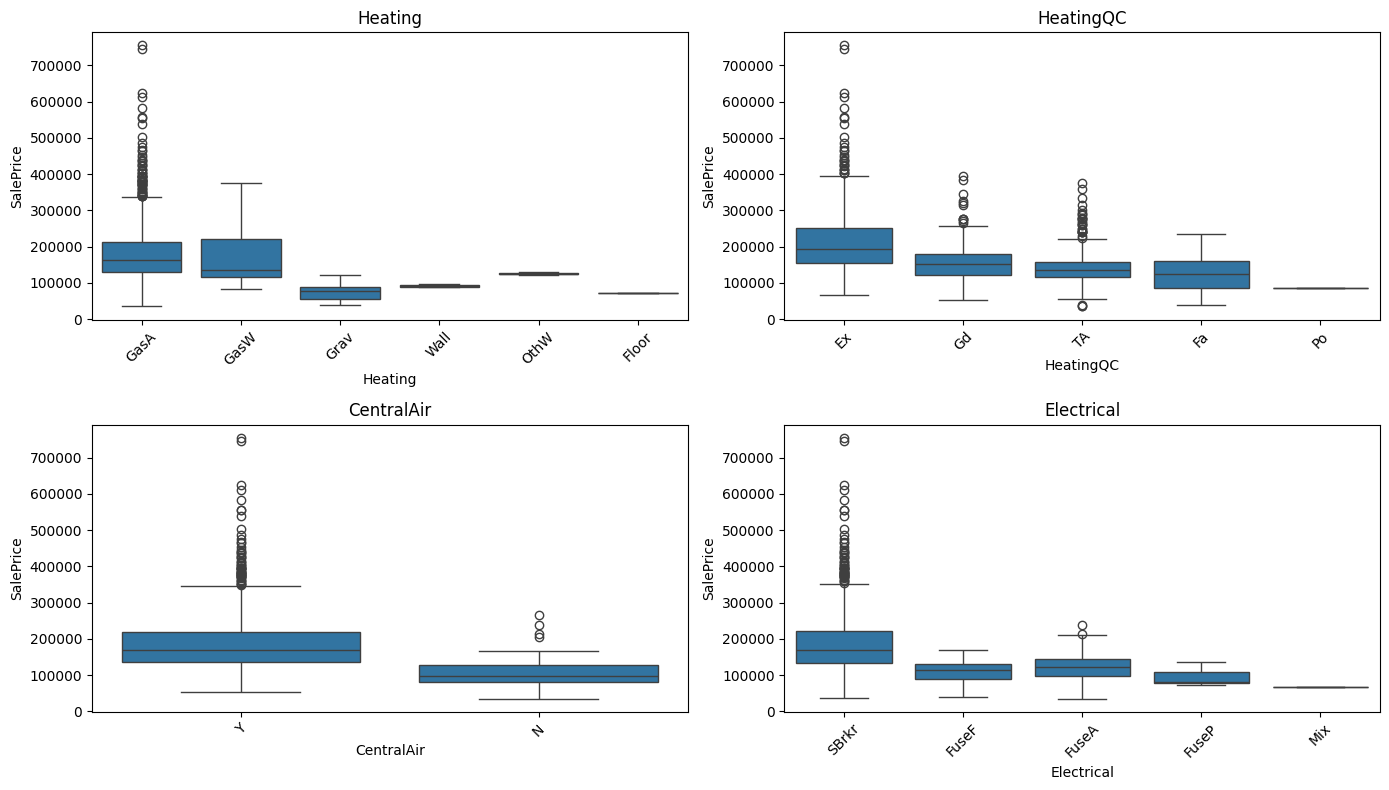

In [59]:
heating_utilities = file[["Heating", "HeatingQC","CentralAir", "Electrical"]]

fig, ax = plt.subplots(2, 2, figsize=(14, 8))
ax = ax.flatten()

for i, col in enumerate(heating_utilities):
    sns.boxplot(data=file, x=col, y="SalePrice", ax=ax[i])
    ax[i].set_title(col)
    ax[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [60]:
heating_utilities = file[["Heating", "HeatingQC","CentralAir", "Electrical"]]

for col in heating_utilities:
    print(f"\n{col}")
    print(file.groupby(col)["SalePrice"].agg(
        count="count",
        median="median",
        mean="mean"
    ).sort_values(by="median", ascending=False))


Heating
         count    median           mean
Heating                                
GasA      1428  164500.0  182021.195378
GasW        18  134950.0  166632.166667
OthW         2  125750.0  125750.000000
Wall         4   91450.0   92100.000000
Grav         7   79000.0   75271.428571
Floor        1   72500.0   72500.000000

HeatingQC
           count    median           mean
HeatingQC                                
Ex           741  194700.0  214914.429150
Gd           241  152000.0  156858.871369
TA           428  135000.0  142362.876168
Fa            49  123500.0  123919.489796
Po             1   87000.0   87000.000000

CentralAir
            count    median           mean
CentralAir                                
Y            1365  168000.0  186186.709890
N              95   98000.0  105264.073684

Electrical
            count    median           mean
Electrical                                
SBrkr        1334  170000.0  186825.113193
FuseA          94  121250.0  122196.89361

House utility features have a noticeable impact on house prices\. Heating quality \(HeatingQC\) and the presence of central air conditioning \(CentralAir\) show strong positive associations with higher sale prices\. The electrical system \(Electrical\) also differentiates house values, with modern systems \(SBrkr\) corresponding to higher prices\. In contrast, the heating type \(Heating\) appears less informative due to the overwhelming dominance of the GasA category and the very small number of observations in the remaining categories\.

# 8- Target Vs Living Area

In [61]:
living_area = file[["1stFlrSF", "2ndFlrSF","LowQualFinSF", "GrLivArea"]]


In [62]:
for col in living_area.columns:
    print(col)
    print(file[[col, "SalePrice"]].corr())
    print("-" * 40)

1stFlrSF
           1stFlrSF  SalePrice
1stFlrSF   1.000000   0.605852
SalePrice  0.605852   1.000000
----------------------------------------
2ndFlrSF
           2ndFlrSF  SalePrice
2ndFlrSF   1.000000   0.319334
SalePrice  0.319334   1.000000
----------------------------------------
LowQualFinSF
              LowQualFinSF  SalePrice
LowQualFinSF      1.000000  -0.025606
SalePrice        -0.025606   1.000000
----------------------------------------
GrLivArea
           GrLivArea  SalePrice
GrLivArea   1.000000   0.708624
SalePrice   0.708624   1.000000
----------------------------------------


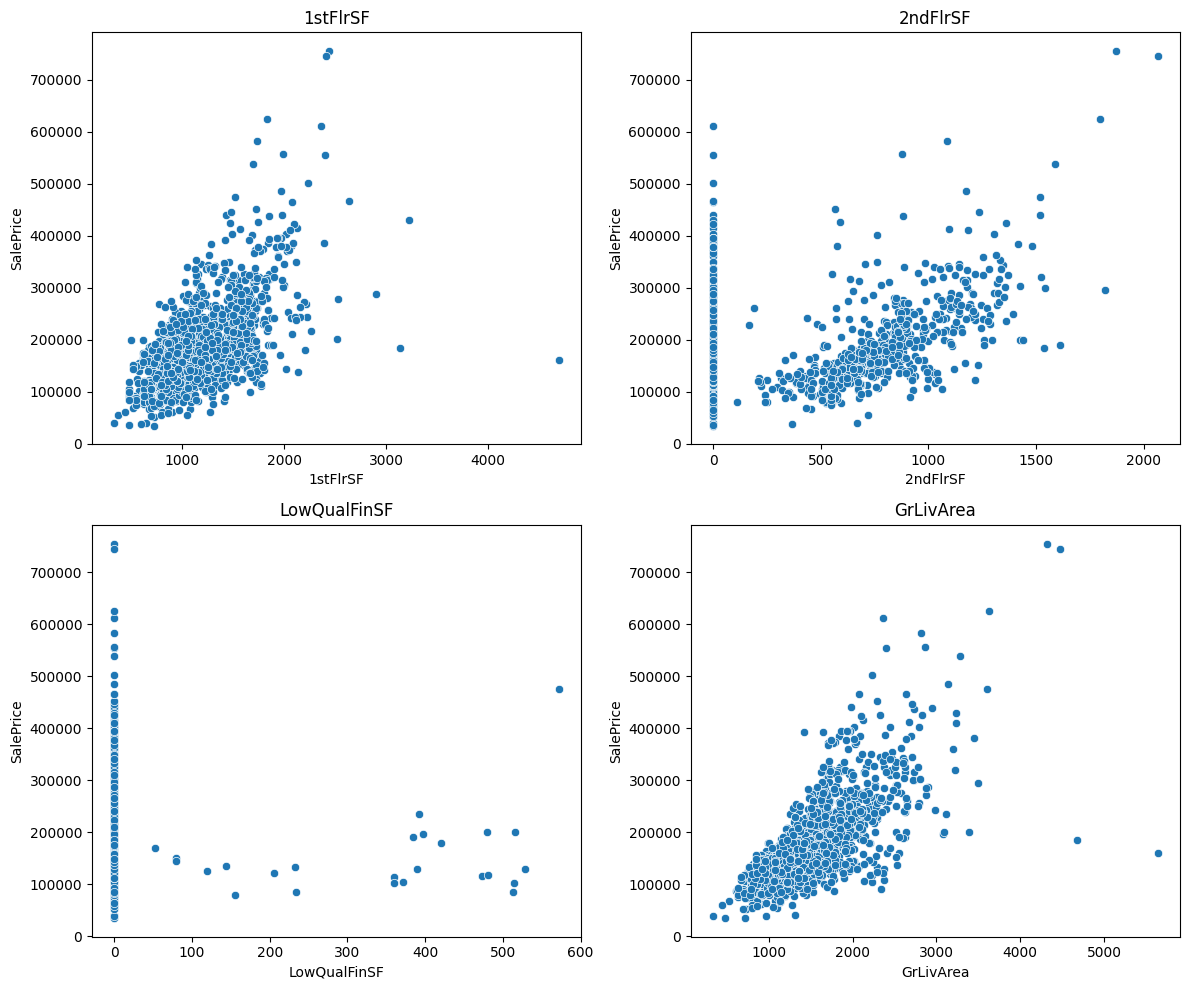

In [63]:
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
ax = ax.flatten()

for i, col in enumerate(living_area.columns):
    sns.scatterplot(data=file, x=col, y="SalePrice", ax=ax[i])
    ax[i].set_title(col)

plt.tight_layout()
plt.show()

GrLivArea is one of the strongest predictors of SalePrice \(r = 0\.709\)\. Houses with larger above\-ground living areas tend to have significantly higher selling prices\.

The first\-floor area has a strong positive relationship with house prices\. Larger first floors are generally associated with higher sale prices\.

The second\-floor area shows a moderate positive relationship with SalePrice\. Homes with larger second floors tend to be more expensive, although the effect is weaker than the first\-floor area\.

LowQualFinSF shows almost no linear relationship with SalePrice, suggesting that low\-quality finished living space contributes little to house value\.

# 9- Target Vs Bathrooms

In [64]:
bathrooms = file[["BsmtFullBath", "BsmtHalfBath","FullBath", "HalfBath"]]


In [65]:
for col in bathrooms.columns:
    print(col)
    print(file[[col, "SalePrice"]].corr())
    print("-" * 40)

BsmtFullBath
              BsmtFullBath  SalePrice
BsmtFullBath      1.000000   0.227122
SalePrice         0.227122   1.000000
----------------------------------------
BsmtHalfBath
              BsmtHalfBath  SalePrice
BsmtHalfBath      1.000000  -0.016844
SalePrice        -0.016844   1.000000
----------------------------------------
FullBath
           FullBath  SalePrice
FullBath   1.000000   0.560664
SalePrice  0.560664   1.000000
----------------------------------------
HalfBath
           HalfBath  SalePrice
HalfBath   1.000000   0.284108
SalePrice  0.284108   1.000000
----------------------------------------


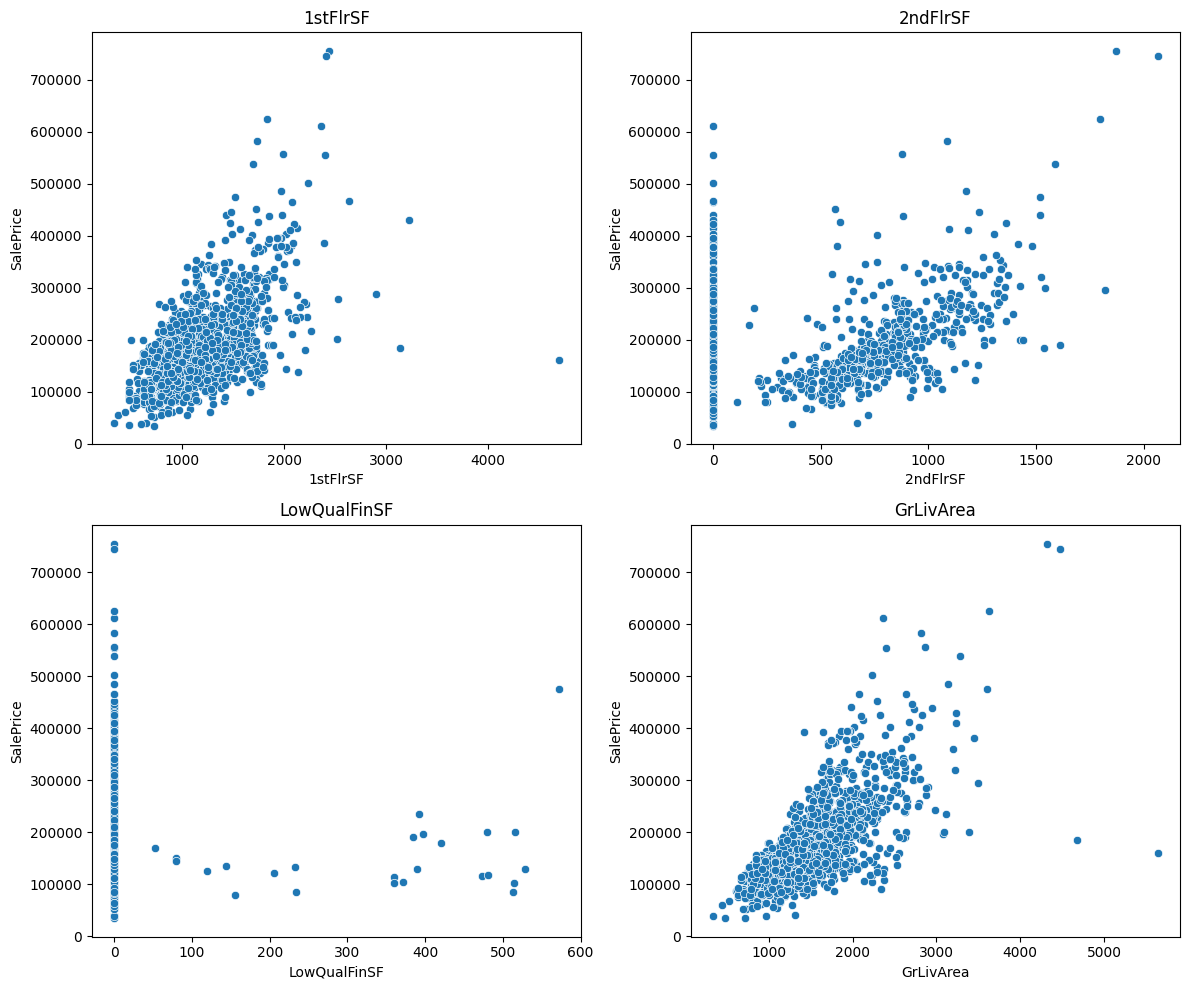

In [66]:
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
ax = ax.flatten()

for i, col in enumerate(living_area.columns):
    sns.scatterplot(data=file, x=col, y="SalePrice", ax=ax[i])
    ax[i].set_title(col)

plt.tight_layout()
plt.show()

FullBath has a strong positive correlation with SalePrice \(r = 0\.561\)\. Houses with more full bathrooms generally achieve higher selling prices\.

HalfBath shows a moderate positive relationship with SalePrice\. Additional half bathrooms increase house value, but their impact is smaller than that of full bathrooms\.

BsmtFullBath has a weak\-to\-moderate positive correlation with SalePrice, indicating that basement full bathrooms contribute positively to house value\.

BsmtHalfBath shows almost no linear relationship with SalePrice, suggesting that basement half bathrooms have little influence on house prices\.

# 10- Target Vs Rooms

In [67]:
rooms = file[["BedroomAbvGr", "KitchenAbvGr","KitchenQual", "TotRmsAbvGrd","Functional"]]


In [68]:
rooms_num = file[["BedroomAbvGr","KitchenAbvGr","TotRmsAbvGrd"]]

for col in rooms_num.columns:
    print(col)
    print(file[[col, "SalePrice"]].corr())
    print("-"*40)

BedroomAbvGr
              BedroomAbvGr  SalePrice
BedroomAbvGr      1.000000   0.168213
SalePrice         0.168213   1.000000
----------------------------------------
KitchenAbvGr
              KitchenAbvGr  SalePrice
KitchenAbvGr      1.000000  -0.135907
SalePrice        -0.135907   1.000000
----------------------------------------
TotRmsAbvGrd
              TotRmsAbvGrd  SalePrice
TotRmsAbvGrd      1.000000   0.533723
SalePrice         0.533723   1.000000
----------------------------------------


TotRmsAbvGrd has a strong positive correlation with SalePrice \(r = 0\.534\)\. Houses with more rooms above ground generally have higher selling prices\.

BedroomAbvGr shows only a weak positive relationship with SalePrice, indicating that the number of bedrooms alone is not a strong indicator of house value\.

KitchenAbvGr has a weak negative correlation with SalePrice \(r = \-0\.136\)\. Houses with multiple kitchens are relatively uncommon and are often older or divided properties, which may explain the slight decrease in selling prices\.

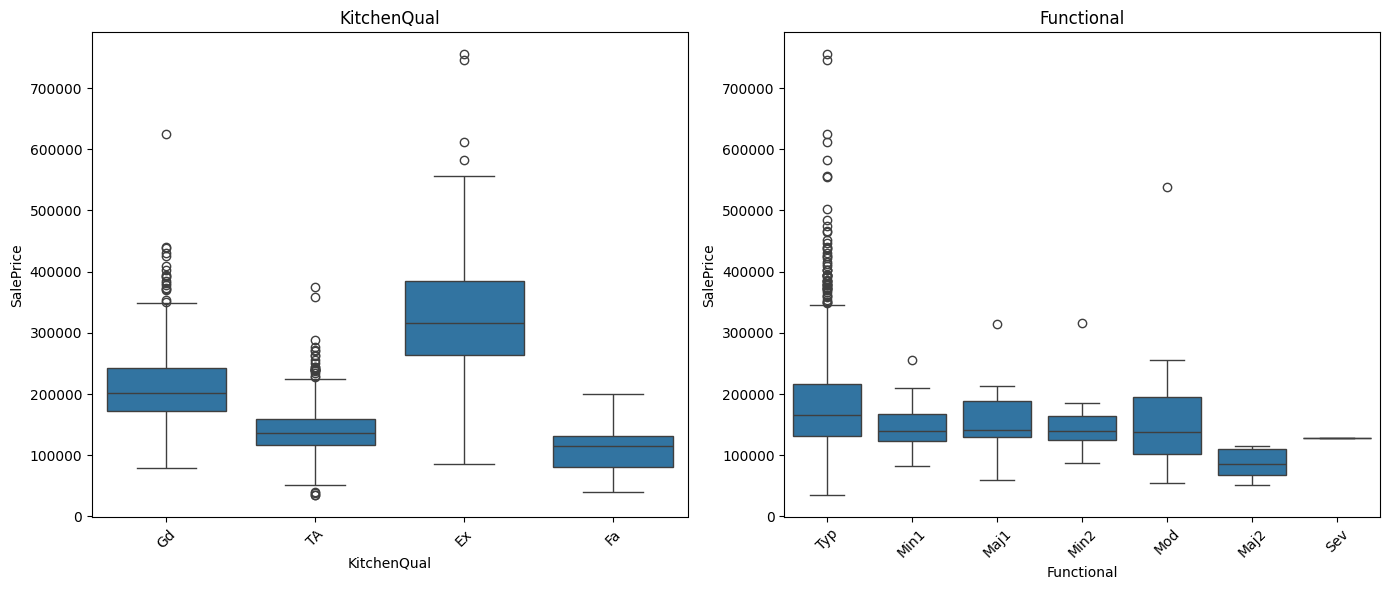

In [69]:
rooms_cat = file[["KitchenQual","Functional"]]

features = ["KitchenQual", "Functional"]

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

for i, col in enumerate(features):
    sns.boxplot(data=file, x=col, y="SalePrice", ax=ax[i])
    ax[i].set_title(col)
    ax[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# 11- Target Vs Fireplace

In [70]:
fireplace = file[["Fireplaces", "FireplaceQu"]]


In [71]:
file[['Fireplaces','SalePrice']].corr()

,Fireplaces,SalePrice
Fireplaces,1.000000,0.466929
SalePrice,0.466929,1.000000


Fireplaces show a moderate positive correlation with SalePrice \(r = 0\.467\), indicating that houses with more fireplaces tend to have higher selling prices\. Although fireplaces contribute positively to house value, their impact is smaller than major structural features such as overall quality or living area\.

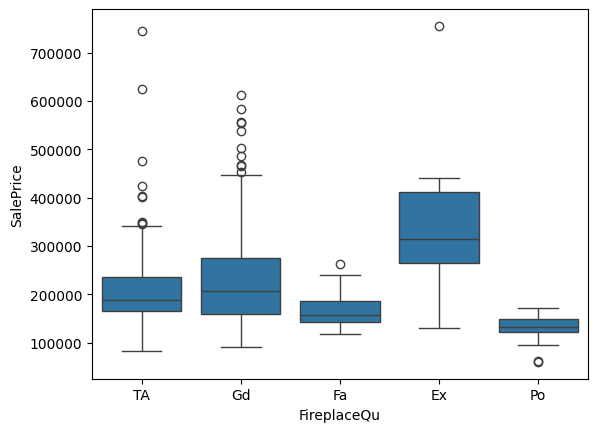

In [72]:
sns.boxplot(data=file,x='FireplaceQu',y='SalePrice')
plt.show()

# 12- Target Vs Garage

In [73]:
garage = file[["GarageType", "GarageYrBlt","GarageFinish", "GarageCars","GarageArea", "GarageQual","GarageCond", "PavedDrive"]]


In [74]:
garage_num = file[["GarageYrBlt","GarageCars","GarageArea"]]

for col in garage_num.columns:
    print(col)
    print(file[[col, "SalePrice"]].corr())
    print("-"*40)

GarageYrBlt
             GarageYrBlt  SalePrice
GarageYrBlt     1.000000   0.486362
SalePrice       0.486362   1.000000
----------------------------------------
GarageCars
            GarageCars  SalePrice
GarageCars    1.000000   0.640409
SalePrice     0.640409   1.000000
----------------------------------------
GarageArea
            GarageArea  SalePrice
GarageArea    1.000000   0.623431
SalePrice     0.623431   1.000000
----------------------------------------


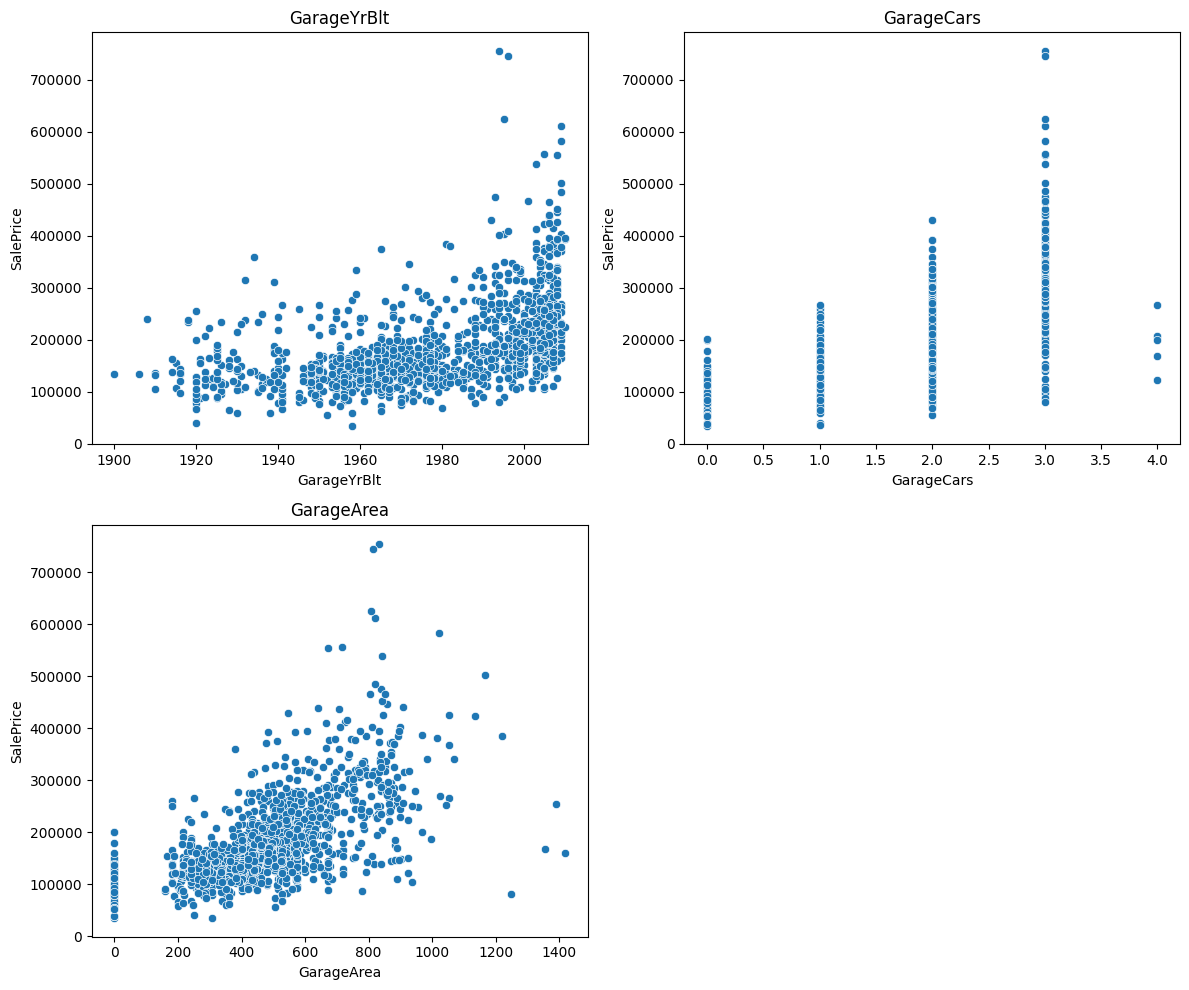

In [75]:
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
ax = ax.flatten()

for i, col in enumerate(garage_num.columns):
    sns.scatterplot(data=file, x=col, y="SalePrice", ax=ax[i])
    ax[i].set_title(col)

fig.delaxes(ax[3])

plt.tight_layout()
plt.show()

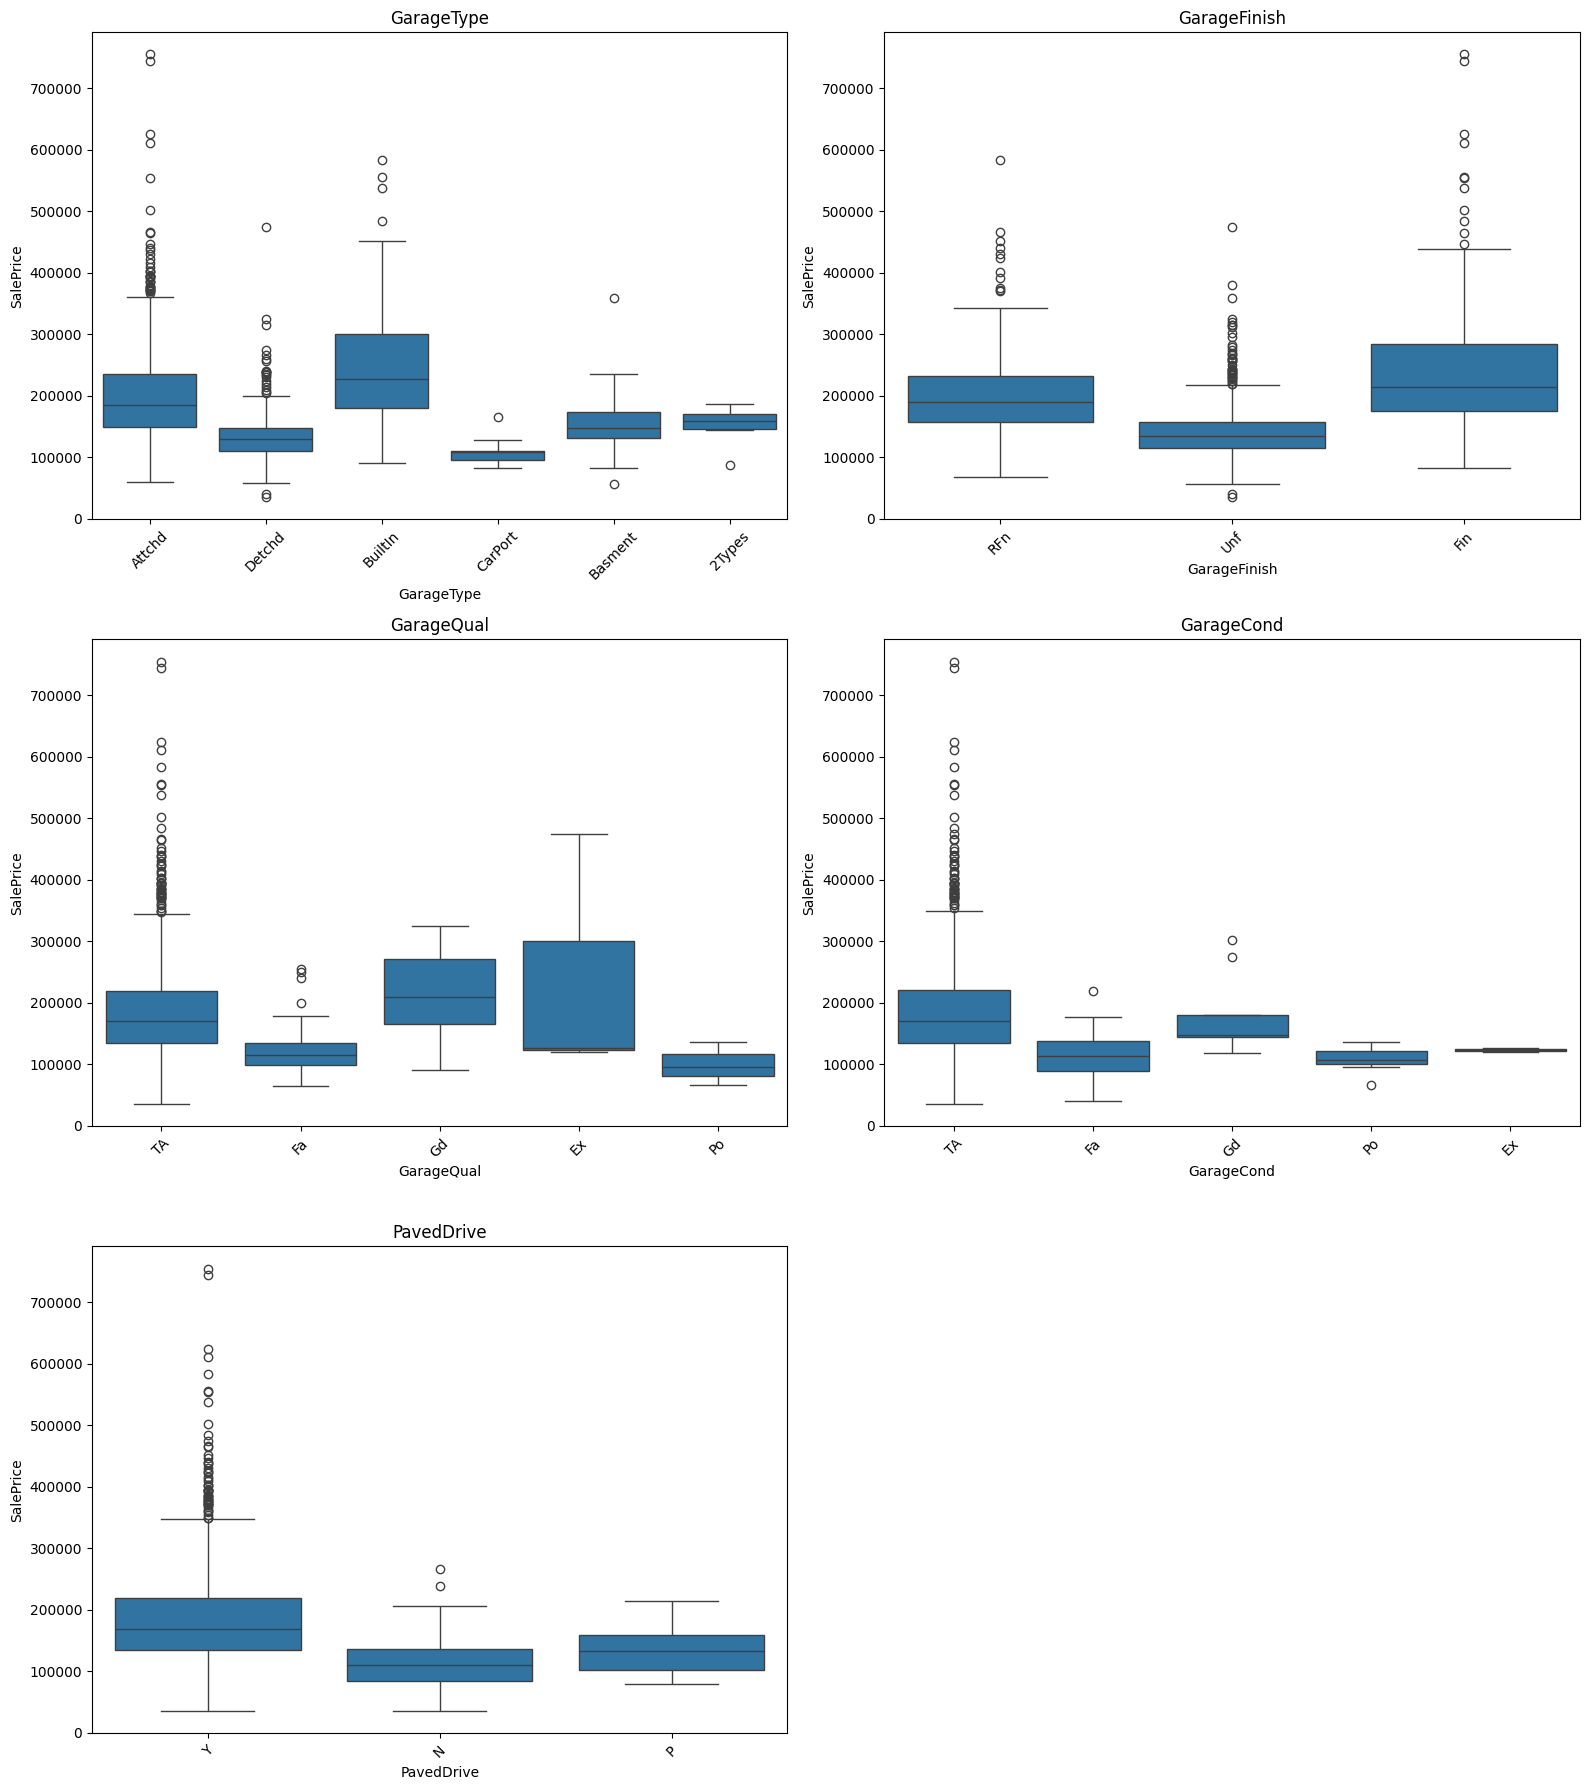

In [76]:
garage_cat = file[["GarageType","GarageFinish","GarageQual","GarageCond","PavedDrive"]]

fig, ax = plt.subplots(3, 2, figsize=(16, 18))
ax = ax.flatten()

for i, col in enumerate(garage_cat):
    sns.boxplot(data=file, x=col, y="SalePrice", ax=ax[i])
    ax[i].set_title(col)
    ax[i].tick_params(axis="x", rotation=45)

fig.delaxes(ax[-1])

plt.tight_layout()
plt.show()

# 13- Target Vs Outdoor Features

In [77]:
outdoor_features = file[["WoodDeckSF", "OpenPorchSF","EnclosedPorch", "3SsnPorch","ScreenPorch", "PoolArea","PoolQC", "Fence","MiscFeature", "MiscVal"]]


In [78]:
outdoor_features_num = file[["WoodDeckSF","OpenPorchSF","EnclosedPorch","3SsnPorch","ScreenPorch","PoolArea","MiscVal"]]

outdoor_features_cat = file[["PoolQC","Fence","MiscFeature"]]

In [79]:
for col in outdoor_features_num.columns:
    print(col)
    print(file[[col, "SalePrice"]].corr())
    print("-" * 40)

WoodDeckSF
            WoodDeckSF  SalePrice
WoodDeckSF    1.000000   0.324413
SalePrice     0.324413   1.000000
----------------------------------------
OpenPorchSF
             OpenPorchSF  SalePrice
OpenPorchSF     1.000000   0.315856
SalePrice       0.315856   1.000000
----------------------------------------
EnclosedPorch
               EnclosedPorch  SalePrice
EnclosedPorch       1.000000  -0.128578
SalePrice          -0.128578   1.000000
----------------------------------------
3SsnPorch
           3SsnPorch  SalePrice
3SsnPorch   1.000000   0.044584
SalePrice   0.044584   1.000000
----------------------------------------
ScreenPorch
             ScreenPorch  SalePrice
ScreenPorch     1.000000   0.111447
SalePrice       0.111447   1.000000
----------------------------------------
PoolArea
           PoolArea  SalePrice
PoolArea   1.000000   0.092404
SalePrice  0.092404   1.000000
----------------------------------------
MiscVal
           MiscVal  SalePrice
MiscVal    1.00000   

WoodDeckSF shows a moderate positive correlation with SalePrice \(r = 0\.324\), suggesting that larger wooden deck areas add value to the property\.

OpenPorchSF has a moderate positive relationship with SalePrice, indicating that larger open porch areas are generally associated with higher house prices\.

EnclosedPorch has a weak negative correlation with SalePrice, suggesting that enclosed porches are more common in older or less expensive homes\.

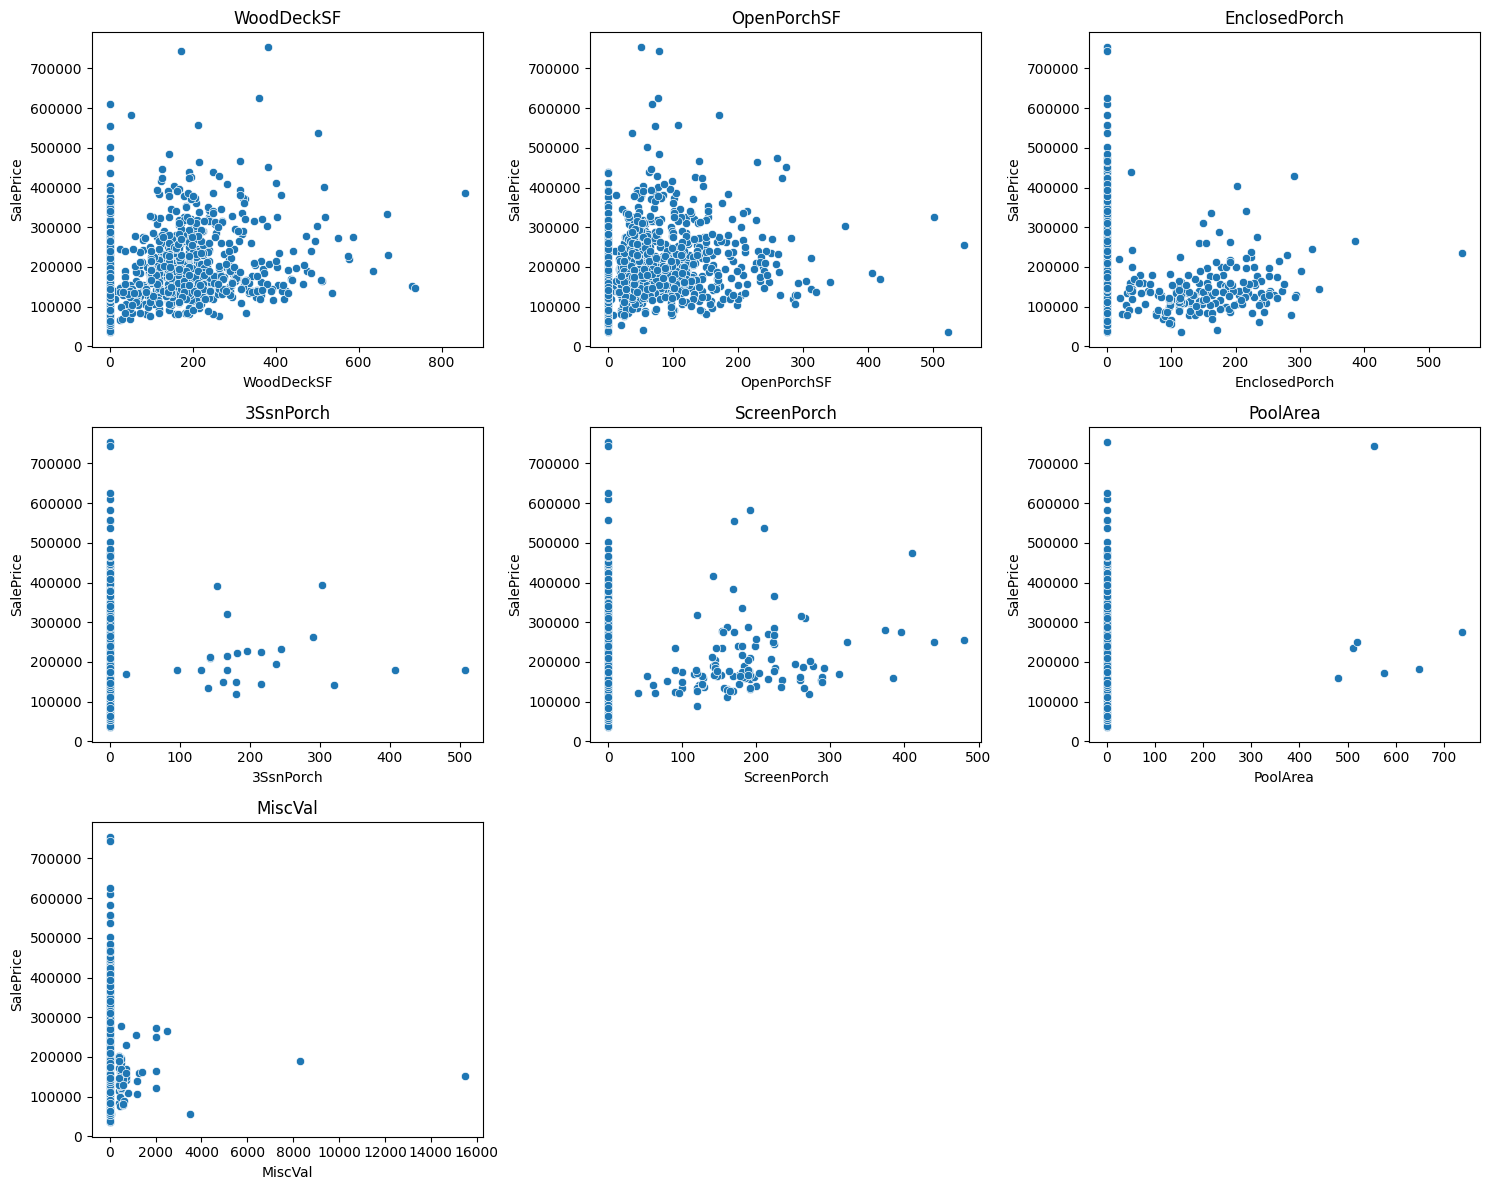

In [80]:
fig, ax = plt.subplots(3, 3, figsize=(15, 12))
ax = ax.flatten()

for i, col in enumerate(outdoor_features_num.columns):
    sns.scatterplot(data=file, x=col, y="SalePrice", ax=ax[i])
    ax[i].set_title(col)

for j in range(len(outdoor_features_num.columns), len(ax)):
    fig.delaxes(ax[j])

plt.tight_layout()
plt.show()

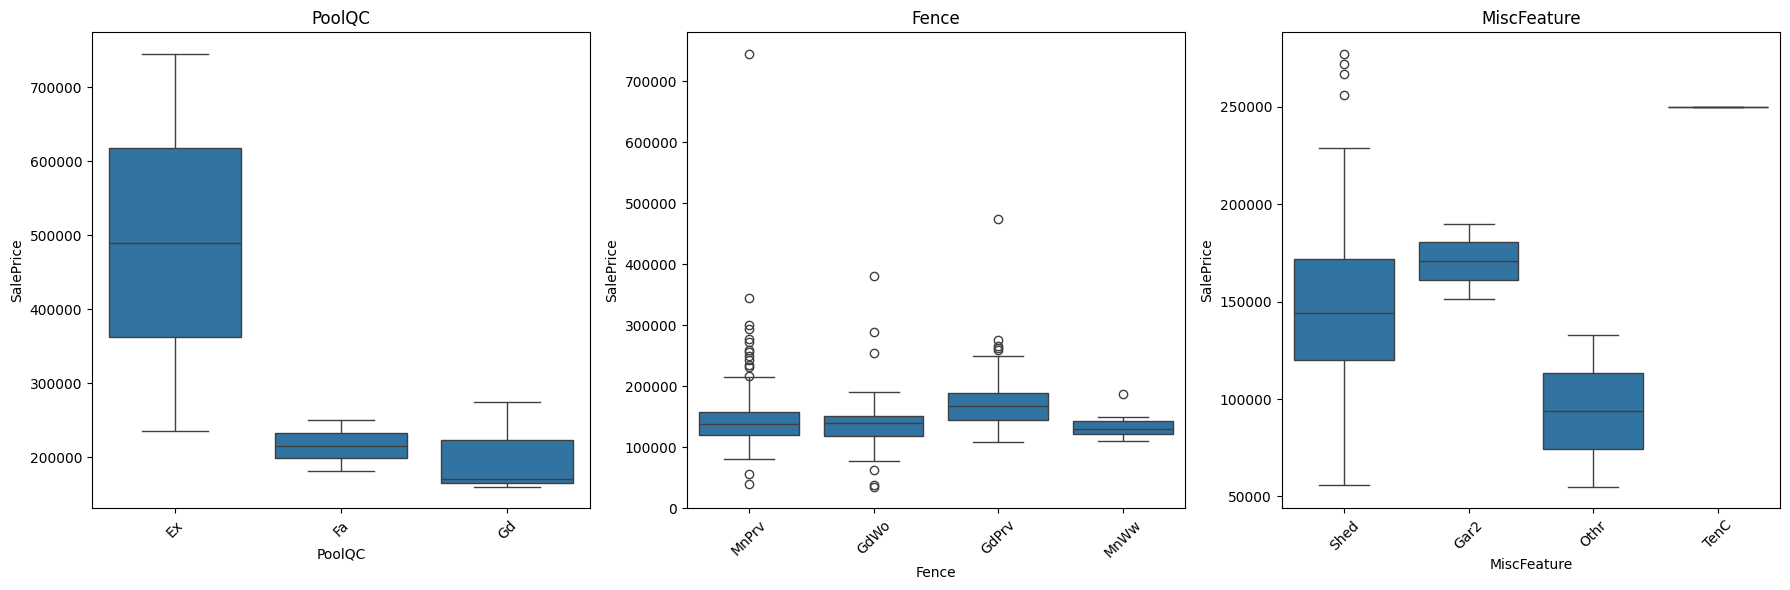

In [81]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(outdoor_features_cat):
    sns.boxplot(data=file, x=col, y="SalePrice", ax=ax[i])
    ax[i].set_title(col)
    ax[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [82]:
for col in outdoor_features_cat:
    print(col)
    print(
        file.groupby(col)["SalePrice"]
        .agg(
            count="count",
            median="median",
            mean="mean"
        )
        .sort_values(by="median", ascending=False)
    )
    print("-"*50)

PoolQC
        count    median      mean
PoolQC                           
Ex          2  490000.0  490000.0
Fa          2  215500.0  215500.0
Gd          3  171000.0  201990.0
--------------------------------------------------
Fence
       count    median           mean
Fence                                
GdPrv     59  167500.0  178927.457627
GdWo      54  138750.0  140379.314815
MnPrv    157  137450.0  148751.089172
MnWw      11  130000.0  134286.363636
--------------------------------------------------
MiscFeature
             count    median           mean
MiscFeature                                
TenC             1  250000.0  250000.000000
Gar2             2  170750.0  170750.000000
Shed            49  144000.0  151187.612245
Othr             2   94000.0   94000.000000
--------------------------------------------------


In [83]:
file.drop(columns="MiscFeature",inplace=True)

PoolQC appears to be associated with higher sale prices, particularly for houses with excellent pool quality\. However, the feature contains only seven observations, making the relationship statistically unreliable\.

Fence quality shows only modest differences in house prices\. Although houses with good privacy fences tend to have slightly higher prices, the overall impact appears limited\.

# 14- Target Vs Sale Information

In [84]:
sale_information = file[["MoSold", "YrSold","SaleType", "SaleCondition","SalePrice"]]

In [85]:
sale_num = file[["MoSold","YrSold"]]

for col in sale_num.columns:
    print(col)
    print(file[[col, "SalePrice"]].corr())
    print("-" * 40)

MoSold
             MoSold  SalePrice
MoSold     1.000000   0.046432
SalePrice  0.046432   1.000000
----------------------------------------
YrSold
             YrSold  SalePrice
YrSold     1.000000  -0.028923
SalePrice -0.028923   1.000000
----------------------------------------


MoSold shows almost no linear relationship with SalePrice \(r = 0\.046\), indicating that the month of sale has little direct influence on house prices\.

YrSold has virtually no linear correlation with SalePrice \(r = \-0\.029\), suggesting that the year of sale does not significantly affect house prices within this dataset\.

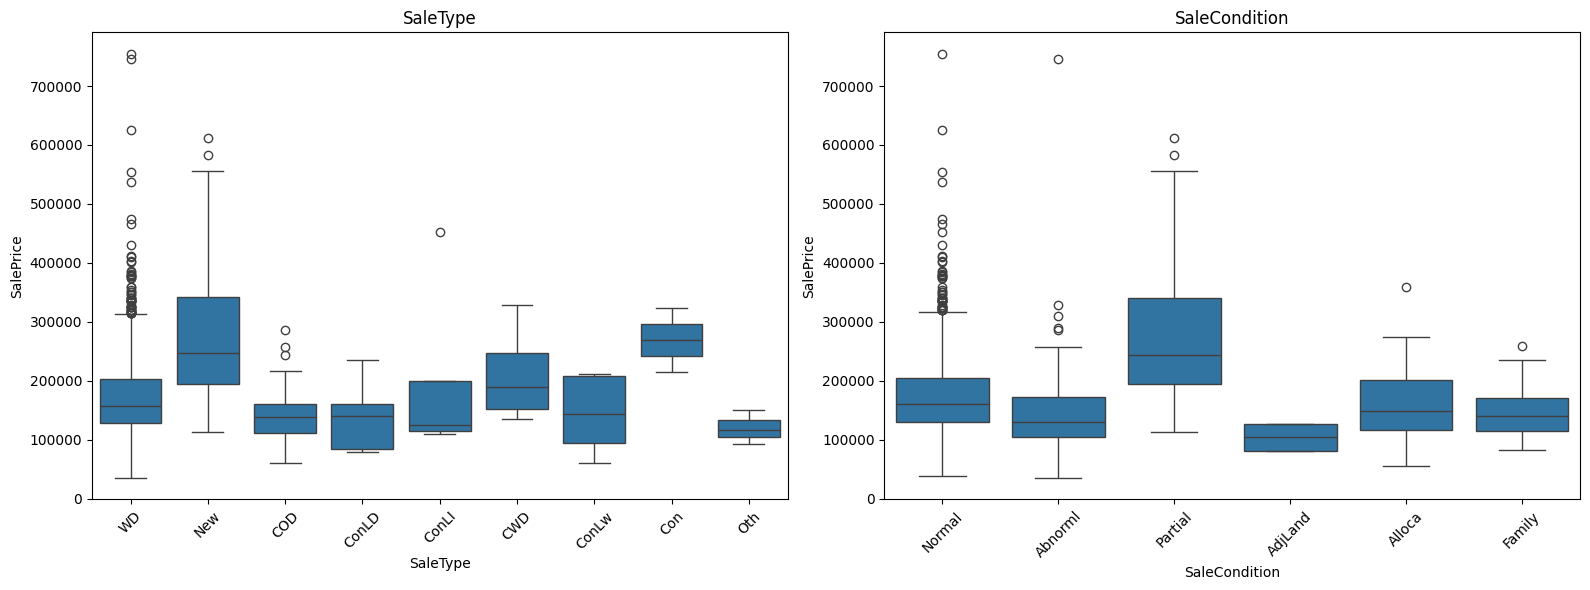

In [86]:

sale_cat = ["SaleType", "SaleCondition"]

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

for i, col in enumerate(sale_cat):
    sns.boxplot(data=file, x=col, y="SalePrice", ax=ax[i])
    ax[i].set_title(col)
    ax[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [87]:
for col in sale_cat:
    print(f"\n{'='*50}")
    print(col)

    print(
        file.groupby(col)["SalePrice"]
        .agg(
            count="count",
            median="median",
            mean="mean"
        )
        .sort_values(by="median", ascending=False)
    )


SaleType
          count    median           mean
SaleType                                
Con           2  269600.0  269600.000000
New         122  247453.0  274945.418033
CWD           4  188750.0  210600.000000
WD         1267  158000.0  173401.836622
ConLw         5  144000.0  143700.000000
ConLD         9  140000.0  138780.888889
COD          43  139000.0  143973.255814
ConLI         5  125000.0  200390.000000
Oth           3  116050.0  119850.000000

SaleCondition
               count    median           mean
SaleCondition                                
Partial          125  244600.0  272291.752000
Normal          1198  160000.0  175202.219533
Alloca            12  148145.0  167377.416667
Family            20  140500.0  149600.000000
Abnorml          101  130000.0  146526.623762
AdjLand            4  104000.0  104125.000000


SaleType influences house prices, with newly constructed homes \(New\) achieving substantially higher selling prices than the standard sale type \(WD\)\. However, several sale types contain very few observations, so their results should be interpreted cautiously\.

SaleCondition has a strong relationship with SalePrice\. Houses sold under the Partial condition have the highest median selling prices, while abnormal or adjusted land sales tend to have lower prices\. This suggests that the sale condition is an important factor influencing house value\.

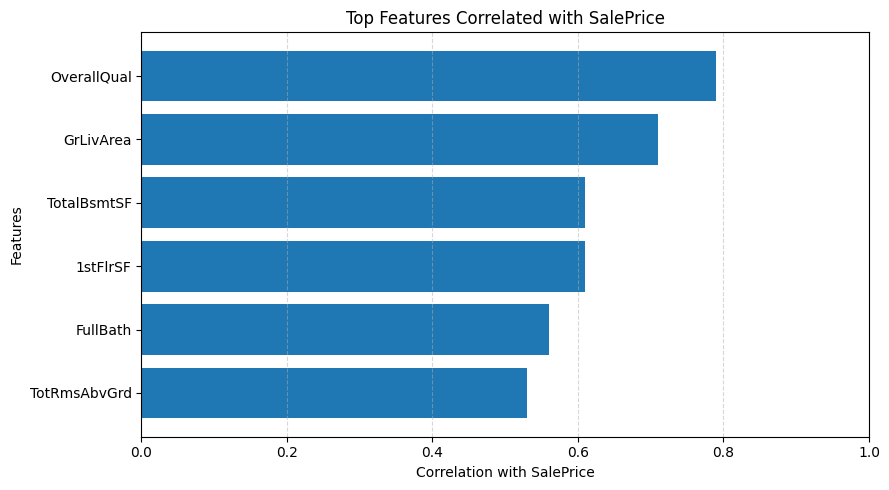

In [ ]:
corr_data = pd.DataFrame({
    "Feature": [
        "OverallQual",
        "GrLivArea",
        "TotalBsmtSF",
        "1stFlrSF",
        "FullBath",
        "TotRmsAbvGrd"
    ],
    "Correlation": [0.79, 0.71, 0.61, 0.61, 0.56, 0.53]
})

plt.figure(figsize=(9,5))
plt.barh(corr_data["Feature"], corr_data["Correlation"])

plt.gca().invert_yaxis()
plt.xlabel("Correlation with SalePrice")
plt.ylabel("Features")
plt.title("Top Features Correlated with SalePrice")
plt.xlim(0, 1)
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

---
---
---

# Deal With Missing Values

In [89]:
file.isnull().sum().sort_values(ascending=False).head(20)


PoolQC          1453
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageCond        81
GarageType        81
GarageFinish      81
GarageYrBlt       81
BsmtExposure      38
BsmtFinType2      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition1         0
Neighborhood       0
LandSlope          0
dtype: int64

### Note: null values in categorical columns mean \(nothing\) ==\> 0

In [90]:
categorical_none = ["PoolQC","Fence","FireplaceQu","GarageType","GarageFinish","GarageQual","GarageCond","BsmtQual","BsmtCond","BsmtExposure","BsmtFinType1","BsmtFinType2"]

file[categorical_none] = file[categorical_none].fillna("0")

In [91]:
numeric_none = [col for col in file.select_dtypes(include=["int64", "float64"]).columns if file[col].isnull().sum() > 0]

In [92]:
numeric_none

['LotFrontage', 'MasVnrArea', 'GarageYrBlt']

In [93]:
file['LotFrontage'].dtype

dtype('float64')

In [94]:
file['LotFrontage']=pd.to_numeric(file['LotFrontage'],errors="coerce")

In [95]:
file['LotFrontage']=file['LotFrontage'].fillna(file['LotFrontage'].median())

In [96]:
file['MasVnrArea']=file['MasVnrArea'].fillna(file['MasVnrArea'].median())

In [97]:
file['GarageYrBlt']=file['GarageYrBlt'].fillna(file['GarageYrBlt'].median())

# Drop Unimportant Features
### [Based on analysis results]

In [98]:
file.drop(columns='Id',inplace=True)

In [99]:
columns_to_drop = [
    "MSSubClass",
    "LotConfig",
    "LandSlope",
    "RoofStyle",
    "BsmtFinSF2",
    "Heating",
    "LowQualFinSF",
    "BsmtHalfBath",
    "KitchenAbvGr",
    "BedroomAbvGr",
    "MiscVal",
    "PoolArea",
    "3SsnPorch",
    "EnclosedPorch",
    "YrSold",
    "MoSold"
]

file.drop(columns=columns_to_drop, inplace=True)

# Deal With Outliers

In [100]:
numerical_cols = file.select_dtypes(include=["int64", "float64"]).columns

for col in numerical_cols:
    Q1 = file[col].quantile(0.25)
    Q3 = file[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((file[col] < lower) | (file[col] > upper)).sum()

    print(f"{col}: {count}")

LotFrontage: 106
LotArea: 69
OverallQual: 2
YearBuilt: 7
YearRemodAdd: 0
MasVnrArea: 98
BsmtFinSF1: 7
BsmtUnfSF: 29
TotalBsmtSF: 61
1stFlrSF: 20
2ndFlrSF: 2
GrLivArea: 31
BsmtFullBath: 1
FullBath: 0
HalfBath: 0
TotRmsAbvGrd: 30
Fireplaces: 5
GarageYrBlt: 1
GarageCars: 5
GarageArea: 21
WoodDeckSF: 32
OpenPorchSF: 77
ScreenPorch: 116
SalePrice: 61


In [101]:
numerical_cols = file.select_dtypes(include=["int64", "float64"]).columns

for col in numerical_cols:
    Q1 = file[col].quantile(0.25)
    Q3 = file[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    file[col] = file[col].clip(lower, upper)

# Encoding

## 1\- Using Ordinal Encoding

In [102]:
cols_with_none = [
    "BsmtQual",
    "BsmtCond",
    "FireplaceQu",
    "GarageQual",
    "GarageCond",
    "PoolQC"
]

for col in cols_with_none:
    file[col] = file[col].replace("0", "None")
    file[col] = file[col].replace(0, "None")

In [ ]:

ordinal_cols = [
    "ExterQual",
    "ExterCond",
    "HeatingQC",
    "KitchenQual",
    "BsmtQual",
    "BsmtCond",
    "FireplaceQu",
    "GarageQual",
    "GarageCond",
    "PoolQC"
]

quality_order = ["None", "Po", "Fa", "TA", "Gd", "Ex"]

encoder = OrdinalEncoder(
    categories=[quality_order] * len(ordinal_cols)
)

file[ordinal_cols] = encoder.fit_transform(file[ordinal_cols])

## 2\- using Target Encoding

In [104]:
nominal_cols = [
    col for col in file.select_dtypes(include=["object"]).columns
    if col not in ordinal_cols
]

In [105]:
for col in nominal_cols:
    mean_price = file.groupby(col)["SalePrice"].mean()
    file[col] = file[col].map(mean_price)

# Most Important Features Vs Target

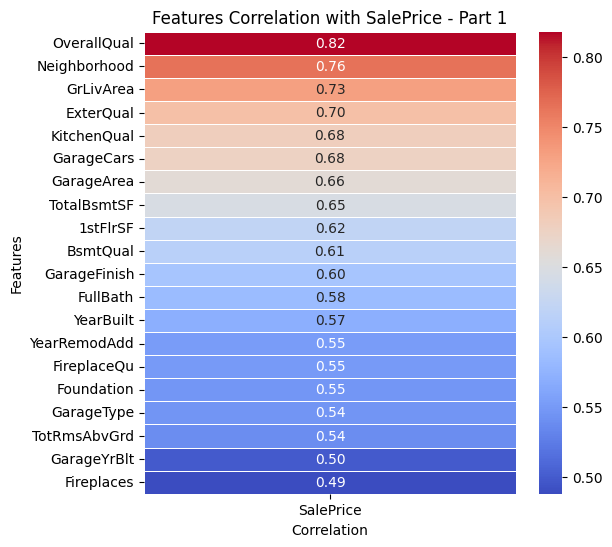

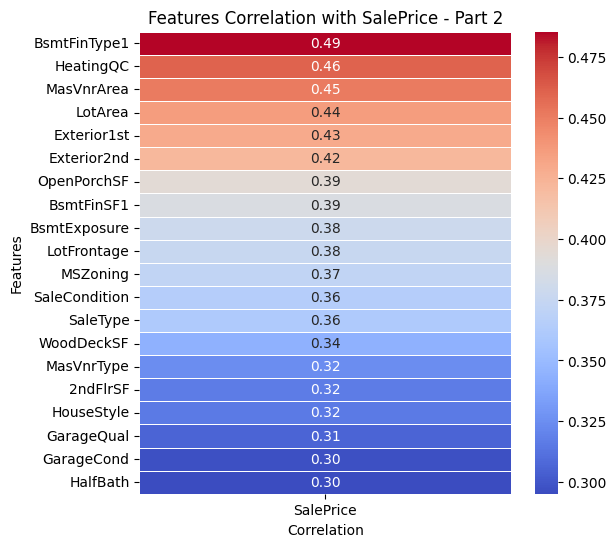

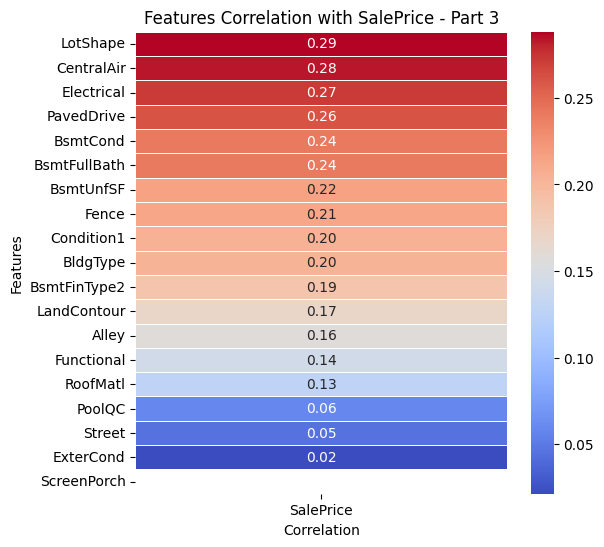

In [114]:
corr = file.corr(numeric_only=True)

sale_corr = corr["SalePrice"].sort_values(ascending=False)

top_corr = sale_corr.drop("SalePrice")

chunks = [top_corr[i:i+20] for i in range(0, len(top_corr), 20)]

for i, chunk in enumerate(chunks[:4]):
    plt.figure(figsize=(6, 6))

    sns.heatmap(
        chunk.to_frame(),
        annot=True,
        cmap="coolwarm",
        linewidths=0.5,
        fmt=".2f"
    )

    plt.title(f"Features Correlation with SalePrice - Part {i+1}")
    plt.ylabel("Features")
    plt.xlabel("Correlation")

    plt.show()

# Select Features And Target

In [107]:
features = file.drop("SalePrice", axis=1)
target = file["SalePrice"]

# Split data to train and test

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(features,target,test_size=.2,random_state=42)

# Normalize Data

In [ ]:
scaler = RobustScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:

imputer = SimpleImputer(strategy="median")

x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

# Select And Train Model

In [ ]:
model_1=LinearRegression()

model_1.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [116]:
y_pred_1 = model_1.predict(x_test)

print("mean_squared_error: ", mean_squared_error(y_test, y_pred_1))
print("mean_absolute_error: ", mean_absolute_error(y_test, y_pred_1))
print("r2_score: ", r2_score(y_test, y_pred_1))

mean_squared_error:  413868764.08676475
mean_absolute_error:  15282.345775213009
r2_score:  0.9153512774524141


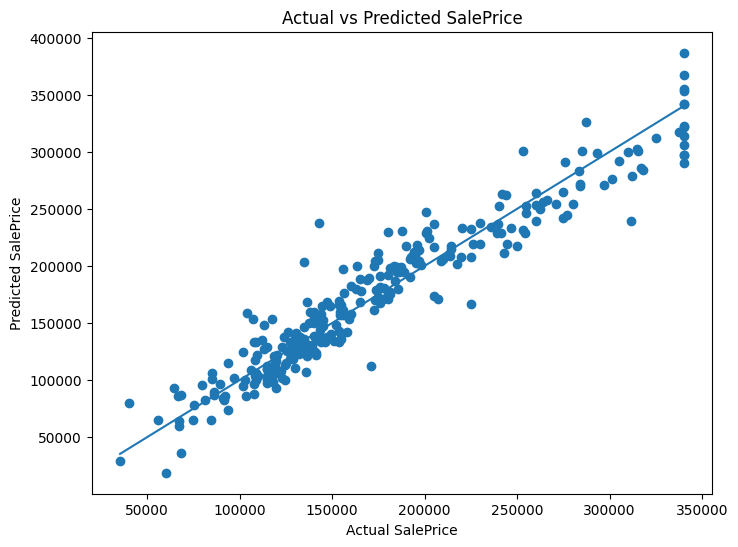

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_1)

plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")

plt.title("Actual vs Predicted SalePrice")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()